# Analysis for the cosmology benchmark (C functions)

## Prelude

In [1]:
%autoreload 2

In [2]:
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import sympy
import matplotlib.pyplot as plt

from pathlib import Path

import AnalysisUtils as au

In [3]:
Path("Results").mkdir(parents=True, exist_ok=True)

In [4]:
x1, x2 = sympy.symbols("x1:3")
x = sympy.abc.x
y = sympy.abc.y
z = sympy.abc.z

## Loading data

These are the results of Jessamine symbolic regression.

In [5]:
full_report = pd.read_csv("For-analysis/full-report.csv")

In [6]:
full_report.run_set.unique()

<StringArray>
['CHT-2026-07-20-1300', 'SRB-2026-07-20-1300', 'SRB-2026-07-25-1900']
Length: 3, dtype: str

In [7]:
full_report.sort_values(["run_set", "data_set", "mse"], inplace=True)
f_indices = full_report.data_set.apply(lambda x: x.startswith("C"))
fr2 = full_report.loc[f_indices].set_index(["run_set", "data_set", "sample_num"])

In [8]:
fr2["sympy"] = fr2.expr_original_syms.apply(au.parse_if_needed)
fr2["sympy_defuzz"] = fr2.expr_original_syms_defuzz.apply(au.parse_if_needed)

Out of all the run sets, these are the two that will be analyzed and reported.

In [9]:
srb_key = "SRB-2026-07-20-1300"
srb_extra_key = "SRB-2026-07-25-1900"
cht_key = "CHT-2026-07-20-1300"

In [10]:
srb = fr2.loc[srb_key]
cht = fr2.loc[cht_key]

In [11]:
srb.groupby(level=["data_set"]).size()

data_set
C1a    32
C1b    32
C1c    32
C1d    32
C2a    32
C2b    32
C3a    32
C3b    32
C3c    32
C3d    32
C3e    32
C3f    32
C3g    32
C3h    32
C4a    32
C4b    32
C4c    32
C4d    32
C4e    32
C5a    32
C5b    32
C5c    32
C5d    32
C5e    32
C5f    32
C6a    32
C6b    32
C6c    32
dtype: int64

These are the best ones overall

In [12]:
srb_min_mse_ixs = srb.groupby(level=["data_set"]).mse.idxmin()

In [13]:
srb.loc[srb_min_mse_ixs, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
C1a,26,8.186385e-14,26,0.00108729814168707*z**0.5 - 0.004174131474966...
C1b,18,2.077038e-04,137,0.0478423427909643*z + 0.0153622680421468*((z ...
C1c,11,3.849757e-09,81,-9.85948336912888e-5*omega_m - 0.0348646272935...
C1d,25,7.744129e-08,64,-10.9494946576292*H0*omega_m**2*z + 1.62086117...
C2a,27,3.800840e-27,8,-H + 0.0715898499999237*z + 0.0715898499999132
C2b,13,3.177178e-09,68,-5.49752962633355e-5*eos + 0.00171941920515774...
C3a,32,1.532695e-13,30,0.920158612447882*z**2 + 0.0847316377256921*z ...
C3b,26,3.872880e-14,100,0.0473854062161096*z - 0.309255951972743*(1 + ...
C3c,31,3.390628e-07,192,-1.135613634872*f2*(2*z - 1.43087630777115) + ...


In [14]:
cht_min_mse_ixs = cht.groupby(level=["data_set"]).mse.idxmin()

In [15]:
srb_threshold_table = au.mse_threshold_table(srb)
srb_threshold_table

,mse_min,mse_med,mse_max,mse00,mse04,mse08,mse12,mse16,mse20,mse24,mse28,mse32
data_set,,,,,,,,,,,,
C1a,8.186385e-14,6.049559e-13,1.719380e-12,32,32,32,27,0,0,0,0,0
C1b,2.077038e-04,2.161854e-04,2.277609e-04,32,0,0,0,0,0,0,0,0
C1c,3.849757e-09,7.503136e-09,1.880730e-08,32,32,23,0,0,0,0,0,0
C1d,7.744129e-08,2.610189e-07,5.094405e-07,32,32,0,0,0,0,0,0,0
C2a,3.800840e-27,4.284107e-27,5.142896e-27,32,32,32,32,32,32,32,0,0
C2b,3.177178e-09,2.618392e-08,7.298259e-08,32,32,2,0,0,0,0,0,0
C3a,1.532695e-13,1.104470e-12,4.286826e-12,32,32,32,12,0,0,0,0,0
C3b,3.872880e-14,1.072133e-12,7.907081e-12,32,32,32,14,0,0,0,0,0
C3c,3.390628e-07,5.747577e-07,9.531591e-07,32,32,0,0,0,0,0,0,0


In [16]:
cht_threshold_table = au.mse_threshold_table(cht)
cht_threshold_table

,mse_min,mse_med,mse_max,mse00,mse04,mse08,mse12,mse16,mse20,mse24,mse28,mse32
data_set,,,,,,,,,,,,
C1a,1.901937e-14,8.848193e-13,1.961561e-12,32,32,32,23,0,0,0,0,0
C1b,2.100352e-04,2.140025e-04,3.459340e-04,32,0,0,0,0,0,0,0,0
C1c,1.137811e-09,5.538984e-09,1.318247e-08,32,32,31,0,0,0,0,0,0
C1d,8.414105e-08,2.175524e-07,4.222586e-07,32,32,0,0,0,0,0,0,0
C2a,3.271090e-27,3.996824e-27,5.014262e-27,32,32,32,32,32,32,32,0,0
C2b,1.602142e-09,1.176813e-08,3.882239e-08,32,32,12,0,0,0,0,0,0
C3a,1.302673e-14,8.805190e-13,4.261896e-12,32,32,32,18,0,0,0,0,0
C3b,2.285324e-14,2.530312e-12,8.547479e-01,32,31,31,10,0,0,0,0,0
C3c,1.641539e-07,3.514146e-07,5.317759e-07,32,32,0,0,0,0,0,0,0


In [17]:
au.to_latex(
    srb_threshold_table,
    file="Generated/srb_threshold_table.tex",
    strip_colname_prefix="mse",
)

In [18]:
au.to_latex(
    cht_threshold_table,
    file="Generated/cht_threshold_table.tex",
    strip_colname_prefix="mse",
)

These are problems I ran extra samples of to get better reliability estimates.

In [19]:
fr2.loc[([srb_key, srb_extra_key], ["C3h"]),:]

rating           mse  \
run_set             data_set sample_num                               
SRB-2026-07-20-1300 C3h      26          4.506882e-08  1.668468e-11   
                             17          6.836028e-08  1.862789e-11   
                             14          2.441198e-07  4.265536e-08   
                             22          4.041985e-07  6.161542e-08   
                             24          2.652194e-07  1.263240e-07   
...                                               ...           ...   
SRB-2026-07-25-1900 C3h      50          8.122345e-07  7.402430e-07   
                             25          7.406625e-07  8.433247e-07   
                             106         4.351195e-07  8.510254e-07   
                             113         8.644792e-07  8.876683e-07   
                             30          5.369556e-07  1.219173e-06   

                                         complexity  complexity_defuzz  \
run_set             data_set sample_num                                  
SRB-2026-07-20-1300 C3h      26                 136                 99   
                             17                  74                 74   
                             14                  93                 93   
                             22                  65                 65   
                             24                  87                 87   
...                                             ...                ...   
SRB-2026-07-25-1900 C3h      50                 129                111   
                             25                 127                127   
                             106                256                256   
                             113                 70                 70   
                             30                 317                239   

                                                                                      expr  \
run_set             data_set sample_num                                                      
SRB-2026-07-20-1300 C3h      26          149.13210063029027*x1*x2*x4**2*sin(x3)**2 - 0....   
                             17          0.7687585373919197*x2/x3**3 + 0.00019168715770...   
                             14          101.27148246861641*x1 + 121.34772517008103*x2*...   
                             22          61.19266077058958*sqrt(x1) + 12.91621624079498...   
                             24          1.485778995015455*x1**3 - 9.2706791914943396*x...   
...                                                                                    ...   
SRB-2026-07-25-1900 C3h      50          -10.658461663718372*x1**2 + 23.306249285981848...   
                             25          -43.557544681945997*x1 + 11.311040032637342*x2...   
                             106         -26.746556317600602*x1**2*x3*(x4**2 + 0.969040...   
                             113         -11.64370851317849*sqrt(x1) + 1.45507771464019...   
                             30          -3.3107904514997446e-9*x1**3*x2**3*(1.10063781...   

                                                                               expr_defuzz  \
run_set             data_set sample_num                                                      
SRB-2026-07-20-1300 C3h      26          149.13210063029*x1*x2*x4**2*sin(x3)**2 - 0.001...   
                             17          0.76875853739192*x2/x3**3 + 0.0001916871577045...   
                             14          101.271482468616*x1 + 121.347725170081*x2*(0.0...   
                             22          61.1926607705896*x1**0.5 + 12.916216240795*x1/...   
                             24          1.48577899501546*x1**3 - 9.27067919149434*x1*(...   
...                                                                                    ...   
SRB-2026-07-25-1900 C3h      50          -10.6584616637184*x1**2 + 23.3062492859818*x1 ...   
                             25          -43.557544681946*x1 + 11.3110400326373*x2 + 0.... 

In [20]:
extra_problems = ["C3h", "C5d"]
srb_extra = fr2.loc[([srb_key, srb_extra_key], extra_problems),:]

In [21]:
srb_extra.sort_values("mse", ascending=True).head()

rating           mse  \
run_set             data_set sample_num                               
SRB-2026-07-20-1300 C5d      13          5.250046e-11  1.239954e-24   
SRB-2026-07-25-1900 C5d      13          5.250046e-11  1.239954e-24   
                             87          7.667129e-11  3.472417e-23   
                             141         5.515354e-11  2.076446e-22   
                    C3h      83          4.504638e-08  1.943045e-16   

                                         complexity  complexity_defuzz  \
run_set             data_set sample_num                                  
SRB-2026-07-20-1300 C5d      13                  48                 27   
SRB-2026-07-25-1900 C5d      13                  48                 27   
                             87                  66                 44   
                             141                 83                 57   
                    C3h      83                  35                 13   

                                                                                      expr  \
run_set             data_set sample_num                                                      
SRB-2026-07-20-1300 C5d      13          -4.176770584830999e-13*x1 - 0.9999999999364303...   
SRB-2026-07-25-1900 C5d      13          -4.176770584830999e-13*x1 - 0.9999999999364303...   
                             87          1.00000000009496*x1/x2 - 6.52676030991786e-10*...   
                             141         1.0000000000085956*x1/x2 - 2.705204882791582e-...   
                    C3h      83          1.5374519850286372e-7*x2 + 0.7687660003867536*...   

                                                                               expr_defuzz  \
run_set             data_set sample_num                                                      
SRB-2026-07-20-1300 C5d      13          -x2**2/(x1 + x2)**2 + 3*x2/(x1 + x2) - 3 + (x1...   
SRB-2026-07-25-1900 C5d      13          -x2**2/(x1 + x2)**2 + 3*x2/(x1 + x2) - 3 + (x1...   
                             87          x1/x2 - (x3/(x1/x2 + 1) + 1)**2 + 4 + 5*(-x1/x...   
                             141         x1/x2 - 2.37492186522707*x3**0.5 + 1.987500000...   
                    C3h      83          0.768766000386754*x2/x3**3 + 299.999980868132*...   

                                                                        expr_original_syms  \
run_set             data_set sample_num                                                      
SRB-2026-07-20-1300 C5d      13          -4.176770584830999e-13*R0 - 0.9999999999364303...   
SRB-2026-07-25-1900 C5d      13          -4.176770584830999e-13*R0 - 0.9999999999364303...   
                             87          1.00000000009496*R0/r - 6.52676030991786e-10*s...   
                             141         1.0000000000085956*R0/r - 2.705204882791582e-9...   
                    C3h      83          1.5374519850286372e-7*Omega_m0 + 0.76876600038...   

                                                                 expr_original_syms_defuzz  \
run_set             data_set sample_num                                                      
SRB-2026-07-20-1300 C5d      13          -r**2/(R0 + r)**2 + 3*r/(R0 + r) - 3 + (R0 + r)/r   
SRB-2026-07-25-1900 C5d      13          -r**2/(R0 + r)**2 + 3*r/(R0 + r) - 3 + (R0 + r)/r   
                             87          R0/r - (x/(R0/r + 1) + 1)**2 + 4 + 5*(-R0/r + ...   
                             141         R0/r - 2.37492186522707*x**0.5 + 1.98750000006...   
                    C3h      83          0.768766000386754*Omega_m0/a_av**3 + 299.99998...   

                                                                                     sympy  \
run_set             data_set sample_num                                                      
SRB-2026-07-20-1300 C5d      13          -4.176770584830999e-13*R0 - 0.9999999999364303...   
SRB-2026-07-25-1900 C5d      13          -4.176770584830999e-13*R0 - 0.9999999999364303...   
                  

## Polynomials

In [22]:
data_sets_polynomial = ["C2a"]

In [23]:
srb.loc[data_sets_polynomial]

rating           mse  complexity  \
data_set sample_num                                           
C2a      27          3.005125e-12  3.800840e-27           8   
         29          3.005125e-12  3.938849e-27           8   
         28          3.005125e-12  3.940256e-27           8   
         17          3.005125e-12  3.953677e-27           8   
         6           3.005125e-12  3.955986e-27           8   
         21          3.005125e-12  3.957993e-27           8   
         3           3.005125e-12  4.025418e-27           8   
         19          3.005125e-12  4.027119e-27           8   
         9           3.005125e-12  4.050689e-27           8   
         15          3.005125e-12  4.070258e-27           8   
         11          3.005125e-12  4.104468e-27           8   
         32          3.005125e-12  4.110346e-27           8   
         30          3.005125e-12  4.148858e-27           8   
         4           3.005125e-12  4.180976e-27           8   
         8           3.005125e-12  4.245736e-27           8   
         25          3.005125e-12  4.275454e-27           8   
         16          3.005125e-12  4.292760e-27           8   
         1           3.005125e-12  4.319919e-27           8   
         13          3.005125e-12  4.323792e-27           8   
         26          3.005125e-12  4.330393e-27           8   
         20          3.005125e-12  4.337855e-27           8   
         23          3.005125e-12  4.353674e-27           8   
         24          3.005125e-12  4.364722e-27           8   
         7           3.005125e-12  4.438476e-27           8   
         12          3.005125e-12  4.439259e-27           8   
         22          3.005125e-12  4.543891e-27           8   
         5           3.005125e-12  4.554320e-27           8   
         14          3.005125e-12  4.569753e-27           8   
         2           3.005125e-12  4.658109e-27           8   
         10          3.005125e-12  4.662139e-27           8   
         18          3.005125e-12  4.811485e-27           8   
         31          3.005125e-12  5.142896e-27           8   

                     complexity_defuzz  \
data_set sample_num                      
C2a      27                          8   
         29                          8   
         28                          8   
         17                          8   
         6                           8   
         21                          8   
         3                           8   
         19                          8   
         9                           8   
         15                          8   
         11                          8   
         32                          8   
         30                          8   
         4                           8   
         8                           8   
         25                          8   
         16                          8   
         1                           8   
         13                          8   
         26                          8   
         20                          8   
         23                          8   
         24                          8   
         7                           8   
         12                          8   
         22                          8   
         5                           8   
         14                          8   
         2                           8   
         10                          8   
         18                          8   
         31                          8   

                                                                  expr  \
data_set sample_num                                                      
C2a      27          -0.9999999999987133*x1 + 0.07158984999992371*x...   
         29          -0.999999999998689*x1 + 0.0715898499999266*x2 ...   
         28          -0.99999999999869*x1 + 0.07158984999993034*x2 ...   
         17          -0.9999999999986953*x1 + 0.07158984999993628*x...   
         6 

`C2a` is no problem.

I used to include `C5f` here, but it's a rational function, not a polynomial.
Table on p31 of the cosmology article is confusing, because `C2a` has a reference to $H(z)$ but there's a column of $H$ in the data file and it really is a simple polynomial.
But `C5f`, which looks like the same kind of item, seems to be referring to `C5d` and `C5e` as functions or $R_0$ and $r$.

In [24]:
srb.loc[srb_min_mse_ixs].loc[data_sets_polynomial, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
C2a,27,3.800840e-27,8,-H + 0.0715898499999237*z + 0.0715898499999132


In [25]:
(srb.loc[data_sets_polynomial]
 .sympy_defuzz.apply(lambda e: not e.is_polynomial(x1, x2))
 .groupby(level="data_set")
 .sum())

data_set
C2a    0
Name: sympy_defuzz, dtype: int64

All runs on all polynomial data sets are correct up to fuzz.

## Rational functions

In [26]:
data_sets_rational = ["C3g", "C3h", "C5a", "C5b", "C5c", "C5d", "C5e", "C5f"]

In [27]:
srb.loc[srb_min_mse_ixs].loc[data_sets_rational, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
C3g,3,2.757489e-07,112,15.4071391587514*H + 17.1347289344352*h**2*v**...
C3h,26,1.668468e-11,99,149.13210063029*H*Omega_m0*a_av_tt**2*sin(a_av...
C5a,2,1.109886e-30,9,r/(r**2 + r)**2
C5b,32,2.285526e-04,134,0.48007567144454*r + 0.000588583588934463*x*(e...
C5c,18,1.830520e-02,27,-0.0074488916454265*r**3 + 0.271678877227934*r...
C5d,13,1.239954e-24,27,-r**2/(R0 + r)**2 + 3*r/(R0 + r) - 3 + (R0 + r)/r
C5e,13,6.148184e-10,198,-2.49112456950882*x + 0.0144558993241074*(4.73...
C5f,32,1.501924e-04,53,-0.0651334335262065*R0 + 0.505212643951659*R0/...


```
C3g: no, but MSE is better than reference
C3h: no, but MSE is better than reference
C5a: perfect
C5b: no
C5c: no
C5d: perfect but in a different form, see below
C5e: no, but MSE is not bad
C5f: no
```

In [28]:
C5d_best = srb.loc[srb_min_mse_ixs].loc["C5d"].sympy_defuzz.iloc[0]

In [29]:
C5d_best

-r**2/(R0 + r)**2 + 3*r/(R0 + r) - 3 + (R0 + r)/r

In [30]:
sympy.simplify(sympy.together(C5d_best))

R0**3/(r*(R0**2 + 2*R0*r + r**2))

In [31]:
cht.loc[cht_min_mse_ixs].loc[data_sets_rational, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
C3g,10,1.746819e-07,228,17.7878115094451*H - 10.4042969487236*h**2*(-v...
C3h,28,1.885538e-16,32,0.768766008531352*Omega_m0/a_av**3 - 0.0001244...
C5a,6,6.120179e-31,14,(0.333333333333333*x + 0.666666666666667)/(r*(...
C5b,27,2.594580e-04,55,10.2345043875144*r + 107.424246105292*x + (-25...
C5c,29,1.810014e-02,106,0.0900927355184584*r*((-r - x - 0.344115799896...
C5d,19,1.726662e-24,32,-4*R0**2/(-2*R0 - 2*r)**2 + 2*R0/(-2*R0 - 2*r)...
C5e,32,4.638134e-06,164,-0.00132611783371126*r**2 - 0.0013261178337112...
C5f,17,2.122741e-04,42,-0.0632842563821326*R0 + 1.23703763013638*R0/r...


```
C3g: no, but MSE is better than reference
C3h: perfect after defuzzing
C5a: perfect
C5b: no
C5c: no
C5d: perfect
C5e: no, but MSE is not bad
C5f: no
```

In [32]:
C3h_cht_best = cht.loc[cht_min_mse_ixs].loc["C3h"].sympy_defuzz.iloc[0]

In [33]:
au.replace_near_integer(sympy.expand(C3h_cht_best))

0.768766008531352*Omega_m0/a_av**3 + 299.999988621954*a_av_tt/a_av

In [34]:
C5b_cht_best = cht.loc[cht_min_mse_ixs].loc["C5b"].sympy_defuzz.iloc[0]

In [35]:
sympy.together(C5b_cht_best)

(10.2345043875144*r**3*(2*r + 0.0383393380769155) + 107.424246105292*r**2*x*(2*r + 0.0383393380769155) + r**2*(-256.972384154741*r - 23.3955583228626) + 23.9981035473172*r**2*(2*r - 0.0834412358155945)**2*(2*r + 0.0383393380769155) - 24.0164374771409*r**2*(2*r + 0.0191696690384578)**2*(2*r + 0.0383393380769155) + 20.1501842258798*r**2*(2*r + 0.0383393380769155) + 0.46360998001373*r*x*(2*r + 0.0383393380769155) + 9.41376954444229*r*(2*r + 0.0383393380769155) - 0.248127637494372*r - 0.00475652469006153)/(r**2*(2*r + 0.0383393380769155))

In [36]:
C5d_cht_best = cht.loc[cht_min_mse_ixs].loc["C5d"].sympy_defuzz.iloc[0]

In [37]:
sympy.simplify(sympy.together(sympy.expand(C5d_cht_best)))

R0**3/(r*(R0**2 + 2*R0*r + r**2))

In [38]:
C5e_cht_best = cht.loc[cht_min_mse_ixs].loc["C5e"].sympy_defuzz.iloc[0]

In [39]:
sympy.expand(C5e_cht_best)

0.000323302946210705*R0*r**6 + 0.000969347099810814*R0*r**5 + 0.000646605892421411*R0*r**4*x - 0.00223003403470574*R0*r**4 + 0.00129208830720022*R0*r**3*x - 0.00607001192583273*R0*r**3 - 0.0055361301678216*R0*r**2*x + 0.00522779490021087*R0*r**2 - 0.00617087398369315*R0*r*x + 0.00841352220108872*R0*r + 0.0147795668852752*R0*x - 0.00274603992667253*R0 - 2.56608369667949e-5*R0*x/r - 0.000552547017540664*R0/r - 0.000270717978647008*R0/r**2 + 0.000161651473105353*r**8 + 0.00064632502301076*r**7 + 0.00129321178484282*r**6*x - 0.000480341747246948*r**6 + 0.00387738839924326*r**5*x - 0.00370061410465349*r**5 + 0.00193981767726423*r**4*x**2 - 0.00851211959402688*r**4*x - 0.00145677587493676*r**4 + 0.00387626492160065*r**3*x**2 - 0.0234647235424251*r**3*x + 0.00400669191471614*r**3 - 0.0166083905034648*r**2*x**2 + 0.0174178110295225*r**2*x + 0.00407481901386166*r**2 - 0.0185126219510795*r*x**2 + 0.0297601888094604*r*x + 0.00132887009142677*r - 0.104530265765083*x**2 - 14.4928668107475*x - 13.24

The majority of solutions are not rational functions.

In [40]:
(srb.loc[data_sets_rational]
 .sympy_defuzz
 .apply(lambda e: not e.is_rational_function())
 .groupby(level="data_set").sum())

data_set
C3g    31
C3h    32
C5a    24
C5b    32
C5c    32
C5d    31
C5e    31
C5f    30
Name: sympy_defuzz, dtype: int64

In [41]:
rational_plot_params = {
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0, 399),
    "complexity_binwidth": 20,
    "mse_lims": (1.0e-32, 1.e2),
    "mse_binwidth": 2.0,
    "xlabel": "Complexity (defuzz)",
    "ylabel": "MSE"
}

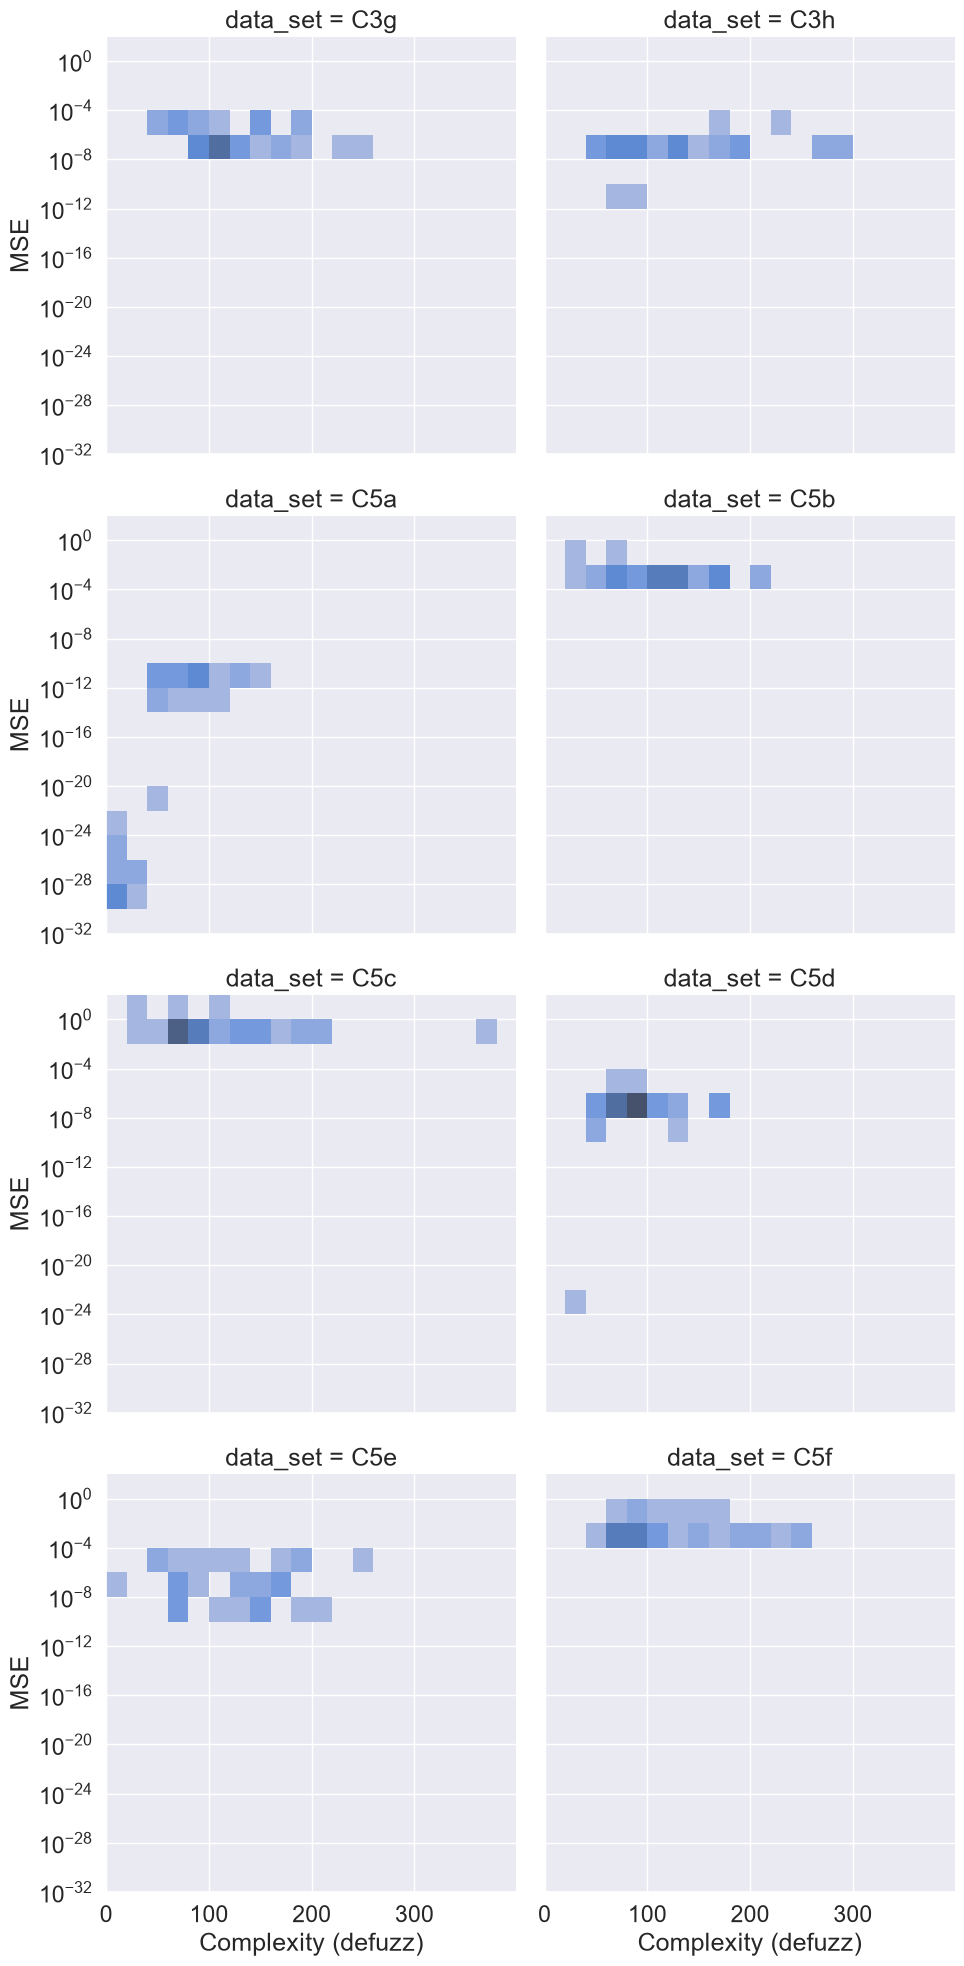

In [42]:
au.complexity_mse_displot(
    srb.loc[data_sets_rational],
    file_stem="srb-rational-complexity-mse-displot",
    **rational_plot_params
)

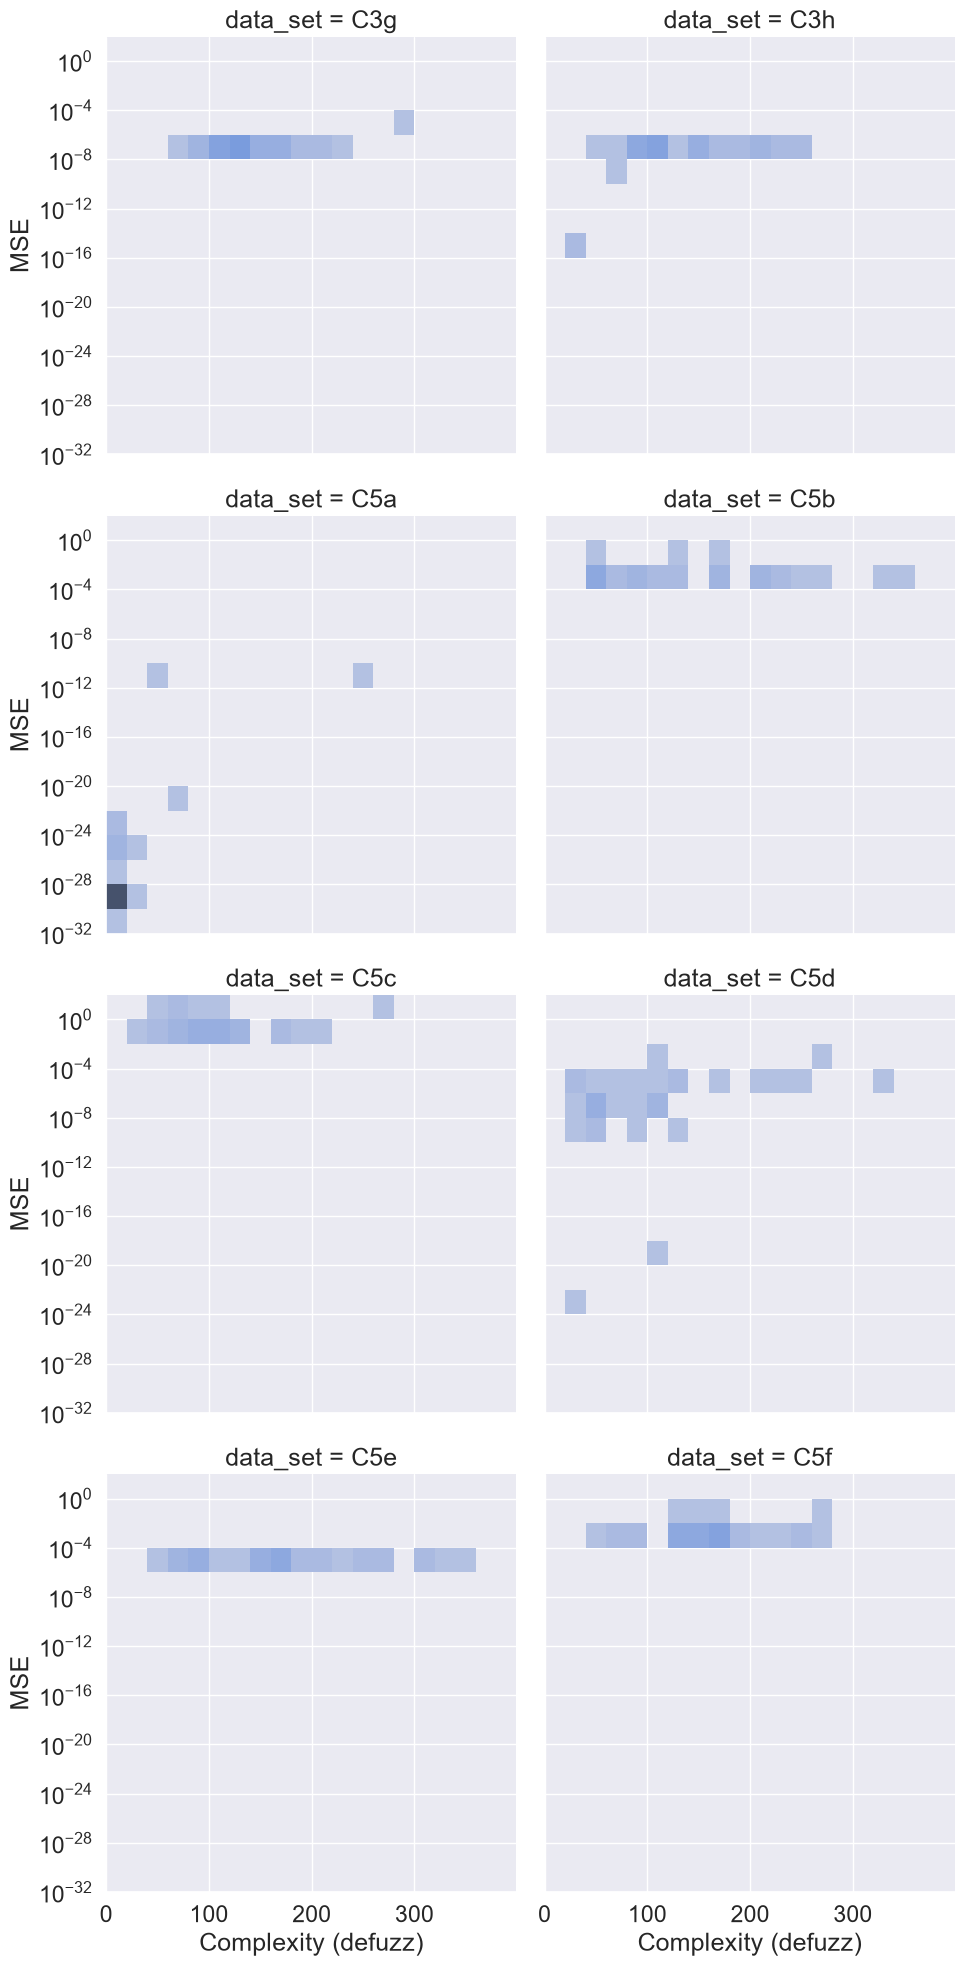

In [43]:
au.complexity_mse_displot(
    cht.loc[data_sets_rational],
    file_stem="cht-rational-complexity-mse-displot",
    **rational_plot_params
)

In [44]:
cht.loc["C3h"].sympy.apply(lambda e: au.replace_near_integer(sympy.expand(e).evalf(), tolerance=1e-3))

sample_num
28    0.768766008531352*Omega_m0/a_av**3 + 300*a_av_...
2     0.768766098404862*Omega_m0/a_av**3 + 300*a_av_...
3     -0.0122820582756831*H**2 + 0.0252949815750476*...
4     -0.00571647589008642*Omega_m0**4 - 0.020791442...
29    -1.91061283252888*H**2*Omega_m0**2/a_av**4 - 0...
15    -152.31940287104*H**2 - 20.9658444037762*H*Ome...
27    0.523620657988029*H**3*Omega_m0/a_av + 33.3355...
30    51.5349158154463*H**3 + 0.00668135009297175*H*...
31    0.0972094569594482*H**4*a_av*a_av_tt + 0.19523...
13    0.0133830289450986*H**4 + 0.0178440385934648*H...
5     0.0168123196332693*H**5 + 0.0336246392665387*H...
20    -60.1494673618924*H**4*Omega_m0**4*a_av_tt/a_a...
22    -0.438568012088364*H**2*a_av**2 + 2.1342966953...
1     -116.149022894398*H**4 - 464.596091577591*H**3...
11    57.8302526210376*H**12*a_av_tt**6/a_av**2 + 37...
25    -9.29050802783114*H**3*a_av**2 - 0.00124178820...
8     -7.33966253060335*H**3 + 7.33966253060335*H**2...
23    -29.6411979752395*H - 14.979629

### More reliability estimates

In [45]:
srb.loc["C5a"].sympy.apply(lambda e: au.replace_near_integer(
    sympy.expand(e.subs(x, 1)).evalf(),
    tolerance=2e-6))

sample_num
2                              r/(r**4 + 2*r**3 + r**2)
11                                1/(r**3 + 2*r**2 + r)
24                                1/(r**3 + 2*r**2 + r)
25                                1/(r**3 + 2*r**2 + r)
4                                 1/(r**3 + 2*r**2 + r)
12                                1/(r**3 + 2*r**2 + r)
21                                1/(r**3 + 2*r**2 + r)
8                                 1/(r**3 + 2*r**2 + r)
15                             r/(r**4 + 2*r**3 + r**2)
30                                1/(r**3 + 2*r**2 + r)
29                                1/(r**3 + 2*r**2 + r)
27                                1/(r**3 + 2*r**2 + r)
18                  -1/(r**2 + 2*r + 1) - 1/(-r**2 - r)
6     -0.00364329642552598*r**3 - 2.64842978669946e-...
22    0.00293324176302762*r - 0.182298181920747*exp(...
10    0.0128083218299184*r - 0.00390739301483585*cos...
26    -0.00115700470442517*r**3 + 0.0008365425770335...
13    -7.97254520927225e-5*r + 1.1000

In [46]:
srb.loc["C5b"].sympy.apply(lambda e: au.replace_near_integer(
    sympy.expand(e.subs(x, 1)).evalf(),
    tolerance=2e-6))

sample_num
32    -0.0137019011567969*r**3 + 0.0611723193373443*...
16    2.15614871003854*r**0.5 + 0.0419359000896496*r...
19    -19.3354226051648*r**0.5 + 0.0465188298677684*...
26    5.88965263047712e-5*r*(r + 1)**0.5*exp(0.07068...
1     0.350064808852465*r**3 - 5.91654570993539*r**2...
27    -0.0506576006556008*r**3 - 0.151972801966803*r...
24    -0.111466634306074*r**2 + 1.2600341875925*r + ...
5     0.0774516185311141*r**2*log(r + 0.136500434487...
31    2.839719265203*r**0.5 + 0.0021164860374865*r**...
18    1.93698204551244*r**2 + 1.4952419353048*r*log(...
3     -73.9833722844462*r + 6.63049815319649*(1 + 0....
23    -0.00621336778473773*r**3 - 0.050097116077217*...
30    0.103645966544316*r + 2.20674052687199e-6*sin(...
17    0.00320984283038516*r**3 - 0.00320984283038516...
28    2.62555328110007*sin(cos(r - 0.036974318242232...
25    -0.0175932794732349*r - 9.86247639509974*log(r...
4     9.27910954934759e-6*r**6 + 0.00014143046216784...
6     0.0337069884311061*r**2 + 0.165

In [47]:
srb.loc["C5c"].sympy.apply(lambda e: au.replace_near_integer(
    sympy.expand(e.subs(x, 1)).evalf(),
    tolerance=2e-6))

sample_num
18    -0.0074488916454265*r**3 + 0.271678877227934*r...
16    -1.82048039439163*r**2 - 0.00360789702630219*r...
10    -0.378034021067525*r**2 - 0.756068042135051*r*...
23    3.97265934376811e-5/r**5.5 + 0.004289766556651...
4     -0.0520277677330736*r**6*sin(1/r) - 0.15608330...
21    23.0169660558136*r**0.5 + 0.0561003181363303*r...
19    -0.00280137179491231*r**4 - 0.0056027435898246...
8     -0.129438767366675*r**2 + 0.750977703317323*r ...
28    -2.34279811571206*r*(r + 1.04370427406621)**0....
30    0.00139170930335794*r**6 + 0.00835025582014765...
31    0.401104188170914*r - 15.0547477009347*r/(2*r ...
11    -0.315691082919159*r**2 + 0.0687487991409821*r...
17    0.0721185209525479*r**4 - 0.0993104105333822*r...
5     -0.2814725936827*r*sin(r + 0.02923371130374125...
3     -0.00017528096571357*r**4 - 0.0001752809657135...
22    0.0319049436870512*r**2 - 0.0870595775627209*r...
24    -0.00183737077203867*r - 0.2610833234252*log(r...
1     -0.277747917826075*r**3 + 1.055

C5d includes a constant column of $x = +1$.
C5e includes a constant column of $x = -1$.

In [48]:
srb.loc["C5d"].sympy.apply(lambda e: au.replace_near_integer(
    sympy.expand(e.subs(x, 1)).evalf(),
    tolerance=0.01))

sample_num
13    R0/r - r**2/(R0**2 + 2*R0*r + r**2) + 3*r/(R0 ...
17    1.52506789846219*R0/r - 0.68582969997412*log(R...
15    0.975822037067009*R0/r + 1.26246112125254*(R0/...
32    R0/r + 2.35629589913876*sin(1.2149407706187545...
11    -0.0143281417359941*R0*(R0/r + 0.1579984419719...
27    R0/r + 28.13702849247*log(R0/r + 0.77875105202...
2     0.828748156680891*R0/r + 0.939891947323826*(0....
10    0.948591233891236*R0/r - 4.95687244860478*(R0/...
22    -0.354422589981085*R0/r + 1.37614299908572*(R0...
18    -0.136613372176311*R0**3/r**3 - 0.720512933262...
29    -0.209303076044945*R0/r + 6.12268032188342*(R0...
24    0.141669099338044*R0/r - 10.2088688355909*(R0/...
3     R0/r + 3.16601497472137*sin(1/(R0/r + 1.407316...
9     4.6368189015969*(R0/r)**0.5 + 2.22736748424691...
5     -1.8002491648362*R0/r + 0.187452741993825*(R0/...
7     -1.63513856964703*R0/r + 2.63224156704596*(R0*...
14    -1.76257835150106*R0/r + 1.95100074896871*(2*R...
1     0.936246042358374*R0/r + 144.57

In [49]:
srb.loc["C5e"].sympy.apply(lambda e: au.replace_near_integer(
    sympy.expand(e.subs(x, -1)).evalf(),
    tolerance=0.01))

sample_num
13    -1.42344996205552*cos(0.016666666666666666 + e...
32    4.91637268463522*exp(sin(2 + exp(-r/R0))) - 24...
20    -0.0647290665877364*(0.157998441971922 + r/R0)...
16    -14.9828827477465*sin(exp(-r/R0)) + 0.97453451...
18    2.63290293245174*exp(0.09122083965542747*exp(-...
26    0.204769257302889*(2*cos(1 - 2*exp(-r/R0)) + 1...
30    3.12100044874003*cos(1 + exp(-r/R0))**2 - 0.07...
10    10.2349009645033*sin(0.10693428670370375 + exp...
27    7.69912981517463*sin(cos(1 - exp(-r/R0)) - 4.7...
28    0.0101793954878781*R0 - 0.0102114686901254*sin...
1     2.1867417283518*sin(r/R0) - 0.0115529604604751...
23    -0.0257594181818279*sin(-13.348273261311025*co...
14    0.013851776357508*exp(-4*exp(-2*r/R0))*exp(6.8...
7     -4.65307986043548*cos(0.5101097961554263 + exp...
5     -84.4833494198687*(r/R0)**0.5 + 220.3073665015...
11    2.60262926686145*sin(1 + exp(-r/R0)) - 2.18973...
19    -0.111322069773618*(r/R0)**0.5 - 0.20321154345...
6     -0.313112120705046*sin(r/R0) - 

### Extra micro-trials

I ran more samples for a few data sets, so now we have 192.

In [50]:
srb_extra.shape

(384, 10)

In [51]:
srb_C3h = srb_extra.loc[([srb_key, srb_extra_key], ["C3h"]),:].sort_values("mse")

There are 3 clearly good ones, so the probability of success in 8h is at least 19.7%

In [52]:
srb_C3h.sympy.iloc[0:10].apply(lambda e: au.replace_near_integer(e.evalf(), tolerance=1.0e-2))

run_set              data_set  sample_num
SRB-2026-07-25-1900  C3h       83            0.768766000386754*Omega_m0/a_av**3 + 300*a_av_...
                               49            0.76876600601774*Omega_m0/a_av**3 + 300*a_av_t...
                               66            0.76876524705348*Omega_m0/a_av**3 + 300*a_av_t...
                               151           -0.113398669096269*H*(1.02531512052443*exp(cos...
SRB-2026-07-20-1300  C3h       26            149.13210063029*H*Omega_m0*a_av_tt**2*sin(a_av...
SRB-2026-07-25-1900  C3h       26            149.13210063029*H*Omega_m0*a_av_tt**2*sin(a_av...
                               17            0.76875853739192*Omega_m0/a_av**3 - 0.64575896...
SRB-2026-07-20-1300  C3h       17            0.76875853739192*Omega_m0/a_av**3 - 0.64575896...
SRB-2026-07-25-1900  C3h       139           -1.27268111766386*H + 0.766400786852584*Omega_...
                               130           0.457514090985405*H*Omega_m0 + 0.7607526792719...
Name: sy

In [53]:
srb_C5d = srb_extra.loc[([srb_key, srb_extra_key], ["C5d"]),:].sort_values("mse")
srb_C5d

rating           mse  \
run_set             data_set sample_num                               
SRB-2026-07-20-1300 C5d      13          5.250046e-11  1.239954e-24   
SRB-2026-07-25-1900 C5d      13          5.250046e-11  1.239954e-24   
                             87          7.667129e-11  3.472417e-23   
                             141         5.515354e-11  2.076446e-22   
                             133         8.906824e-11  2.187367e-15   
...                                               ...           ...   
                             88          1.761824e-07  9.568611e+27   
                             104         2.576095e-07  2.615077e+59   
                             39          3.027380e-08  3.523896e+65   
SRB-2026-07-20-1300 C5d      28          5.233501e-08  2.401881e+85   
SRB-2026-07-25-1900 C5d      28          5.233501e-08  2.401881e+85   

                                         complexity  complexity_defuzz  \
run_set             data_set sample_num                                  
SRB-2026-07-20-1300 C5d      13                  48                 27   
SRB-2026-07-25-1900 C5d      13                  48                 27   
                             87                  66                 44   
                             141                 83                 57   
                             133                 67                 56   
...                                             ...                ...   
                             88                 134                 91   
                             104                 87                 62   
                             39                  90                 71   
SRB-2026-07-20-1300 C5d      28                 255                216   
SRB-2026-07-25-1900 C5d      28                 255                216   

                                                                                      expr  \
run_set             data_set sample_num                                                      
SRB-2026-07-20-1300 C5d      13          -4.176770584830999e-13*x1 - 0.9999999999364303...   
SRB-2026-07-25-1900 C5d      13          -4.176770584830999e-13*x1 - 0.9999999999364303...   
                             87          1.00000000009496*x1/x2 - 6.52676030991786e-10*...   
                             141         1.0000000000085956*x1/x2 - 2.705204882791582e-...   
                             133         -3.0015209672056029*x1/x2 + 4.001534180659143*...   
...                                                                                    ...   
                             88          -11.962651728619682*x1/x2 + 2.4907293265081707...   
                             104         -0.0028536612462273011*x1 + 0.9866318020156596...   
                             39          -2.8251375677818944*x1**2/x2**2 - 0.6370454012...   
SRB-2026-07-20-1300 C5d      28          4.780959155056184*x1/x2 - 0.025778196514196101...   
SRB-2026-07-25-1900 C5d      28          4.780959155056184*x1/x2 - 0.025778196514196101...   

                                                                               expr_defuzz  \
run_set             data_set sample_num                                                      
SRB-2026-07-20-1300 C5d      13          -x2**2/(x1 + x2)**2 + 3*x2/(x1 + x2) - 3 + (x1...   
SRB-2026-07-25-1900 C5d      13          -x2**2/(x1 + x2)**2 + 3*x2/(x1 + x2) - 3 + (x1...   
                             87          x1/x2 - (x3/(x1/x2 + 1) + 1)**2 + 4 + 5*(-x1/x...   
                             141         x1/x2 - 2.37492186522707*x3**0.5 + 1.987500000...   
                             133         -3.0015209672056*x1/x2 + 4.00153418065914*x3*(...   
...                                                                                    ...   
                             88          -11.9626517286197*x1/x2 + 2.49072932650817e-5*...   
                             104         -0.0028536612462273*x1 + 0.98663180201566*x1/x... 

In [54]:
srb_C5d.sympy.iloc[0:5].apply(
    lambda e:
    au.replace_near_integer(
        sympy.simplify(
            sympy.expand(
                sympy.together(
                    au.replace_near_integer(e.subs(x, 1).evalf(), tolerance=2.0e-3)))),
                    tolerance=1e-8)
        )

run_set              data_set  sample_num
SRB-2026-07-20-1300  C5d       13            R0**3/(r*(R0**2 + 2*R0*r + r**2))
SRB-2026-07-25-1900  C5d       13            R0**3/(r*(R0**2 + 2*R0*r + r**2))
                               87            R0**3/(r*(R0**2 + 2*R0*r + r**2))
                               141           R0**3/(r*(R0**2 + 2*R0*r + r**2))
                               133           R0**3/(r*(R0**2 + 2*R0*r + r**2))
Name: sympy, dtype: object

## Power functions

In [55]:
data_sets_power = ["C1a", "C1b", "C1c", "C1d", "C2b"]

In [56]:
srb.loc[srb_min_mse_ixs].loc[data_sets_power, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
C1a,26,8.186385e-14,26,0.00108729814168707*z**0.5 - 0.004174131474966...
C1b,18,2.077038e-04,137,0.0478423427909643*z + 0.0153622680421468*((z ...
C1c,11,3.849757e-09,81,-9.85948336912888e-5*omega_m - 0.0348646272935...
C1d,25,7.744129e-08,64,-10.9494946576292*H0*omega_m**2*z + 1.62086117...
C2b,13,3.177178e-09,68,-5.49752962633355e-5*eos + 0.00171941920515774...


```
C1a: no
C1b: no, although it has a term of roughly the correct form.
C1c: no
C1d: no
C2b: no
````

In [57]:
C1b_best = srb.loc[srb_min_mse_ixs].loc["C1b"].sympy_defuzz.iloc[0]

In [58]:
C1b_best

0.0478423427909643*z + 0.0153622680421468*((z + 0.0591091245598706)**3 + 1)**0.5 + 0.00125837918605417*((z + 0.0591091245598706)**3 + (cos(2*z + 0.05910912455987062) + 0.000262987635483)**3 + (z + (z + 0.0591091245598706)**3 + cos(2*z + 0.05910912455987062) + 0.0593721121953536)**3 + 1.05910912455987)**0.5 - 5.25219334998758e-5*exp((z + 0.05910912455987062)**3) - 0.00553053421570174*sin(z - sqrt((z + 0.05910912455987062)**3 + 1) + (cos(2*z + 0.05910912455987062) + 0.0002629876354829998)**3 + (z + (z + 0.05910912455987062)**3 + cos(2*z + 0.05910912455987062) + 0.05937211219535362)**3 + 1) - 0.00131502561055951*cos(4*z + (z + cos(2*z + 0.05910912455987062) + 0.0002629876354829998)**2 + log(z + (z + 0.05910912455987062)**3 + 1) + 0.05893090360668486 + exp(-sin(z))) + 0.0524176660120074

In [59]:
C1c_best = srb.loc[srb_min_mse_ixs].loc["C1c"].sympy_defuzz.iloc[0]

In [60]:
C1c_best

-9.85948336912888e-5*omega_m - 0.0348646272935208*z**2 - 0.163992846031492*z + 14.0632034054198*(omega_m*z)**0.5 + 7.3296875037977*(-(omega_m*z)**0.5 - 1)**2 - (0.0426783982580598*(omega_m*z)**0.5 + 0.0426783982580598)*(((omega_m*z)**0.5 + 2.025)**2 + 1) - 7.03443593817352*((omega_m*z)**0.5 + 2.025)**2 + 0.0369481300026946*(z + (omega_m*z)**0.5 + 2.025)**2 + 21.6563599862587 - 9.85948336912888e-5/z

In [61]:
au.replace_near_integer(C1c_best, tolerance=1.0e-4)

-0.0348646272935208*z**2 - 0.163992846031492*z + 14.0632034054198*(omega_m*z)**0.5 + 7.3296875037977*(-(omega_m*z)**0.5 - 1)**2 - (0.0426783982580598*(omega_m*z)**0.5 + 0.0426783982580598)*(((omega_m*z)**0.5 + 2.025)**2 + 1) - 7.03443593817352*((omega_m*z)**0.5 + 2.025)**2 + 0.0369481300026946*(z + (omega_m*z)**0.5 + 2.025)**2 + 21.6563599862587

In [62]:
cht.loc[cht_min_mse_ixs].loc[data_sets_power, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
C1a,12,1.901937e-14,72,0.0118415719815248*z**2 + 0.00937770217783341*...
C1b,30,2.100352e-04,97,-0.792766235526861*z + 0.000320598392240145*(2...
C1c,16,1.137811e-09,64,0.0391883835681465*omega_m*z + 0.0040958452333...
C1d,26,8.414105e-08,192,-0.175761688590079*H0*omega_m**0.5*z*(-H0 + z ...
C2b,15,1.602142e-09,145,0.0969160301186917*z + 0.000138012051520437*(z...


Kind of the same.

Let's take a look at the C1a data.
It's just a slight curve.

In [63]:
C1a_df = pd.read_csv("Things-to-bench/cosmo_data/C1a.csv")

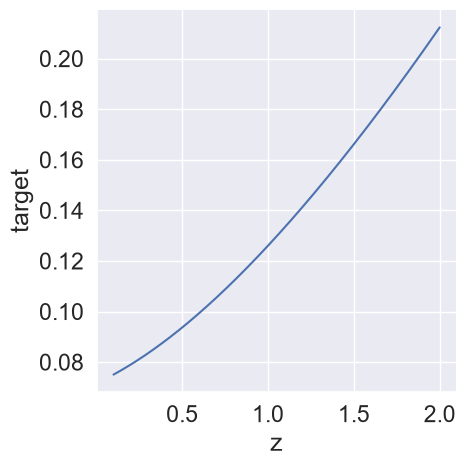

In [64]:
C1a_plot = sns.relplot(data=C1a_df, x="z", y="target", kind="line")

In [65]:
C1a_plot.savefig("Generated/Pictures/C1a_plot.svg")
C1a_plot.savefig("Generated/Pictures/C1a_plot.pdf")

I bet if we gave it something with more shape it would have better luck.

In [66]:
xs = np.linspace(-2.2, 2, 100)
ys = 0.0718 * np.sqrt(0.3 * (1 + xs) ** 3 + 0.7)

<Axes: >

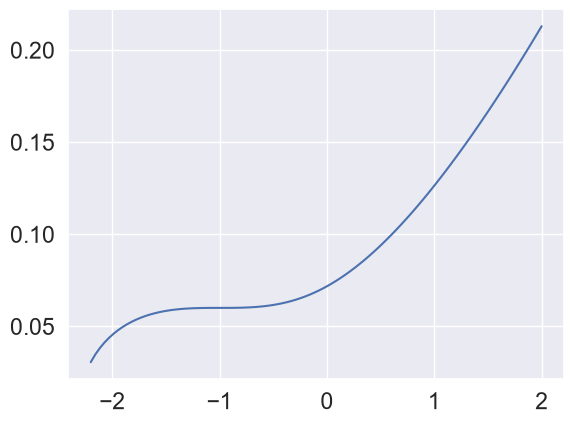

In [67]:
sns.lineplot(x=xs, y=ys)

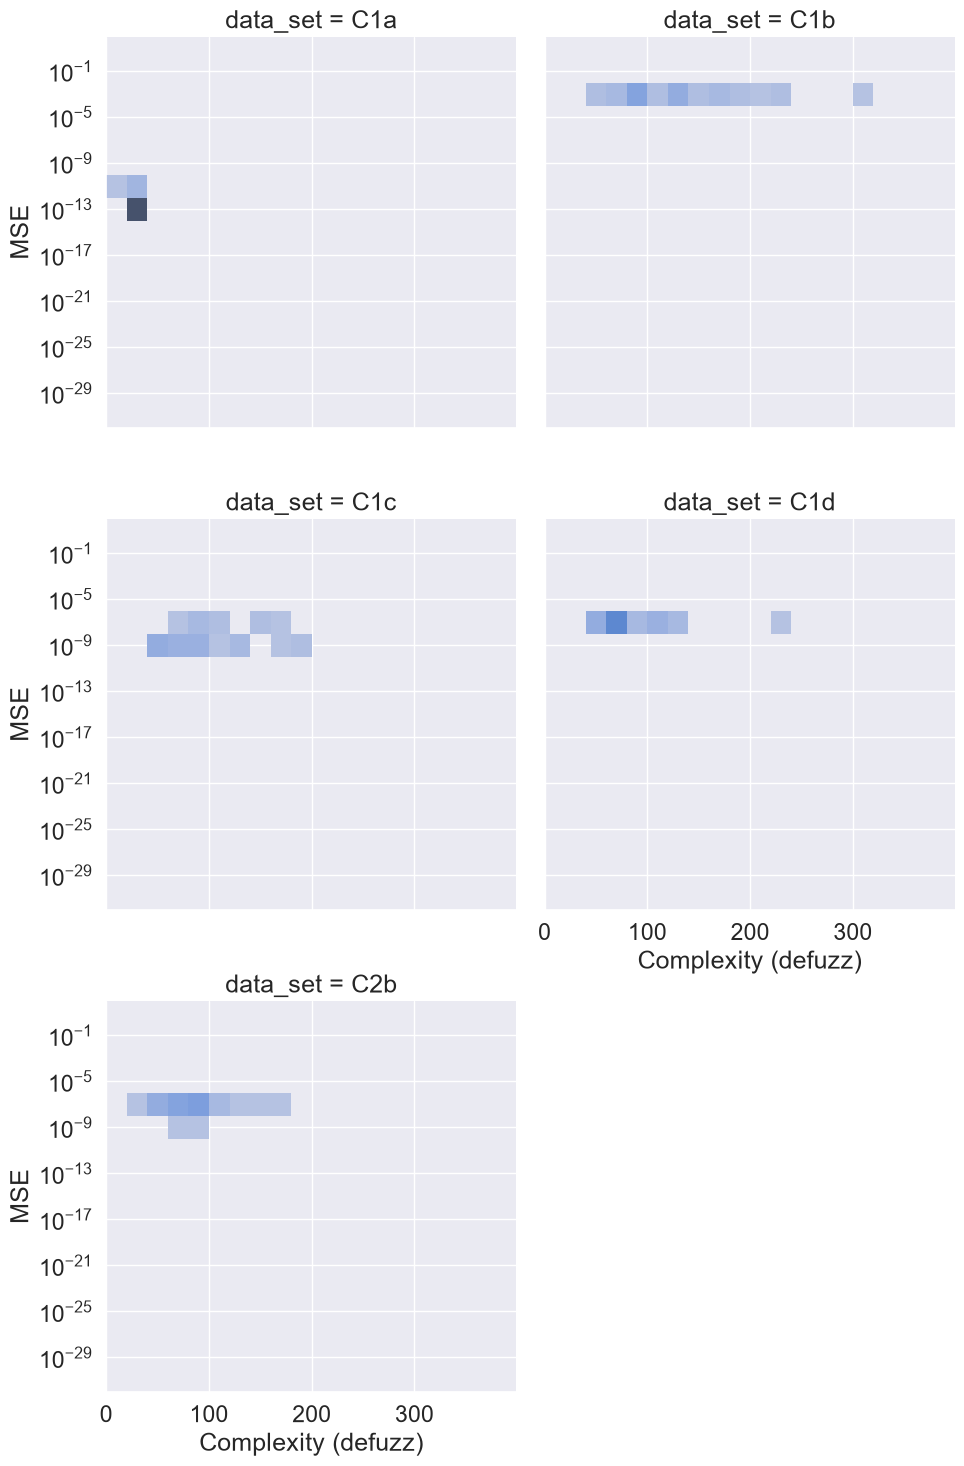

In [68]:
au.complexity_mse_displot(
    srb.loc[data_sets_power],
    file_stem="srb-power-complexity-mse-displot",
    **rational_plot_params
)

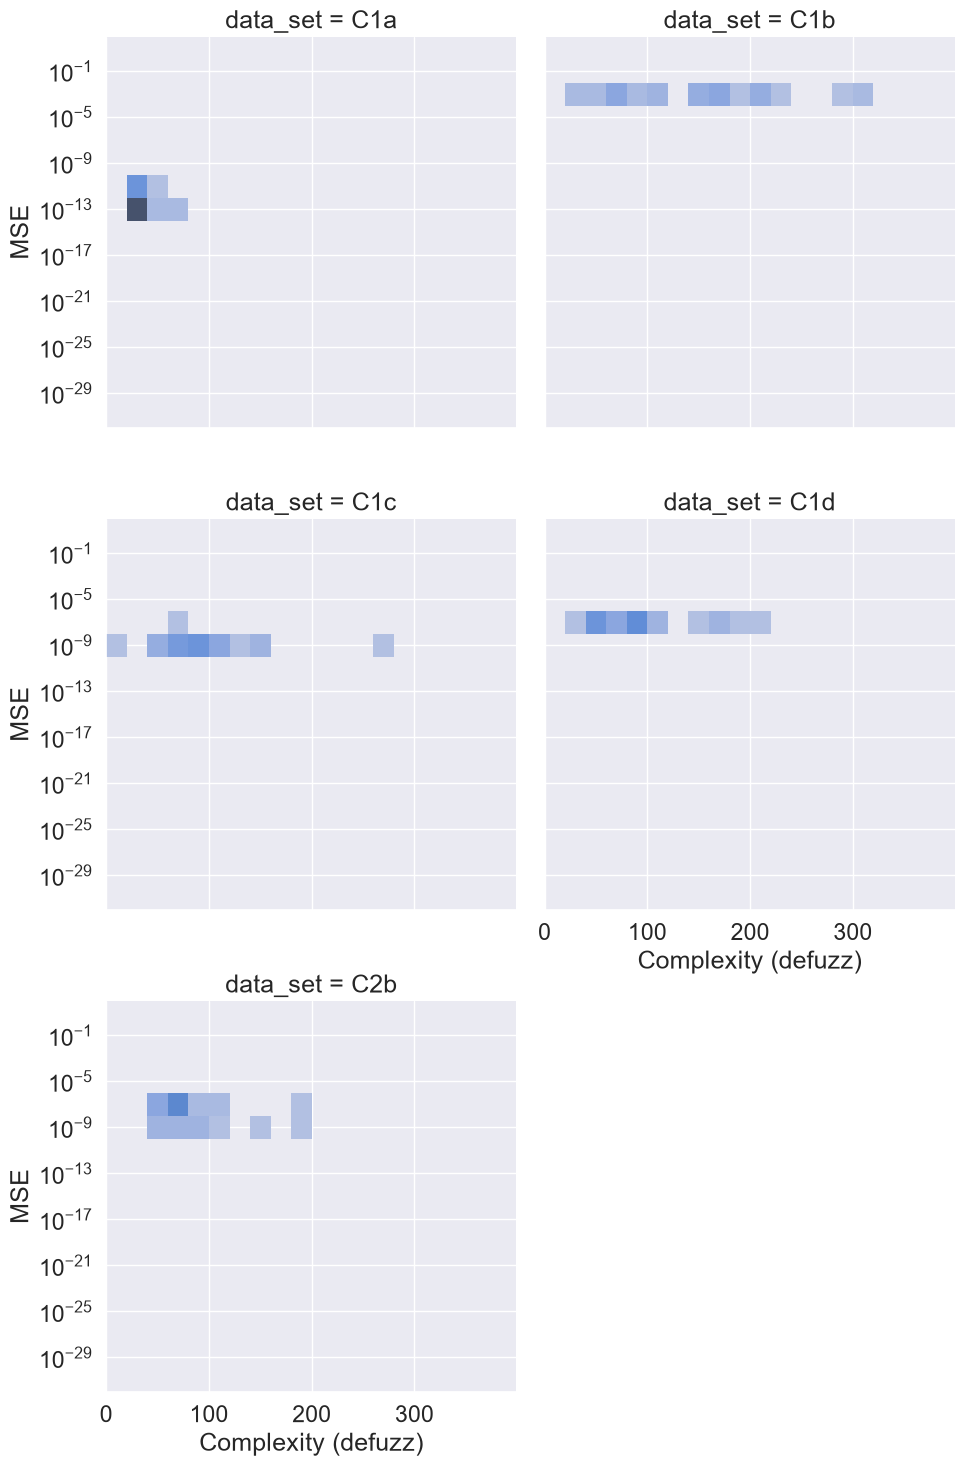

In [69]:
au.complexity_mse_displot(
    cht.loc[data_sets_power],
    file_stem="cht-power-complexity-mse-displot",
    **rational_plot_params
)

## Hard

In [70]:
data_sets_hard = ["C6a", "C6b", "C6c"]

In [71]:
srb.loc[srb_min_mse_ixs].loc[data_sets_hard, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
C6a,23,5.266985e-03,137,-0.000519526179471644*t**3*(t + sin(-(t + 0.02...
C6b,8,8.706919e-07,38,0.00730943553930378*Phi - 0.115597616007377*do...
C6c,31,5.071442e-01,169,0.614434064623275*t**0.5 + 3.85028824695379*t ...


```
C6a: nope
C6b: decent MSE, better than cp3 article, some promising terms
C6c: nope
```

These are the best MSEs from the cp3-bench article.

In [72]:
targets_C6 = [ 0.0022, 1.2e-5, 0.11]
target_map = dict(zip(data_sets_hard, targets_C6))

This sort of bizarre construction makes an index that can be used as a series of thresholds lined up with the rows of `srb_C6`.

In [73]:
srb_C6 = srb.loc[data_sets_hard]
threshold_series = srb_C6.index.get_level_values("data_set").map(target_map)
threshold_series

Index([ 0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,
        0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,
        0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,
        0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,  0.0022,
       1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05,
       1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05,
       1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05,
       1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05, 1.2e-05,
          0.11,    0.11,    0.11,    0.11,    0.11,    0.11,    0.11,    0.11,
          0.11,    0.11,    0.11,    0.11,    0.11,    0.11,    0.11,    0.11,
          0.11,    0.11,    0.11,    0.11,    0.11,    0.11,    0.11,    0.11,
          0.11,    0.11,    0.11,    0.11,    0.11,    0.11,    0.11,    0.11],
      dtype='float64', name='data_set')

In [74]:
C6_threshold_counts = (srb_C6.mse <= threshold_series).groupby(level="data_set").sum()
C6_best = srb_C6.mse.groupby(level="data_set").min()

In [75]:
C6_threshold_table = pd.DataFrame({"best": C6_best, "target": targets_C6, "count": C6_threshold_counts}, index=data_sets_hard)
C6_threshold_table

,best,target,count
C6a,5.266985e-03,0.002200,0
C6b,8.706919e-07,0.000012,17
C6c,5.071442e-01,0.110000,0


In [76]:
C6_threshold_table.to_csv("Results/C6_threshold_table.csv", index=True, header=True)

In [77]:
cht.loc[cht_min_mse_ixs].loc[data_sets_hard, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
C6a,1,0.078593,165,-187.335848017779*t**2 + 3138.92482851253/(exp...
C6b,16,0.063213,221,3.30130099407902*Phi + 5.67447396771543*dotPhi...
C6c,11,0.512765,129,-5.02970685983661*m1*t + 1.6840688661325*t**2 ...


Nope.

In [78]:
hard_plot_params = {
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0, 399),
    "complexity_binwidth": 20,
    "mse_lims": (1.0e-10, 1.e3),
    "mse_binwidth": 1.0,
    "xlabel": "Complexity (defuzz)",
    "ylabel": "MSE"
}

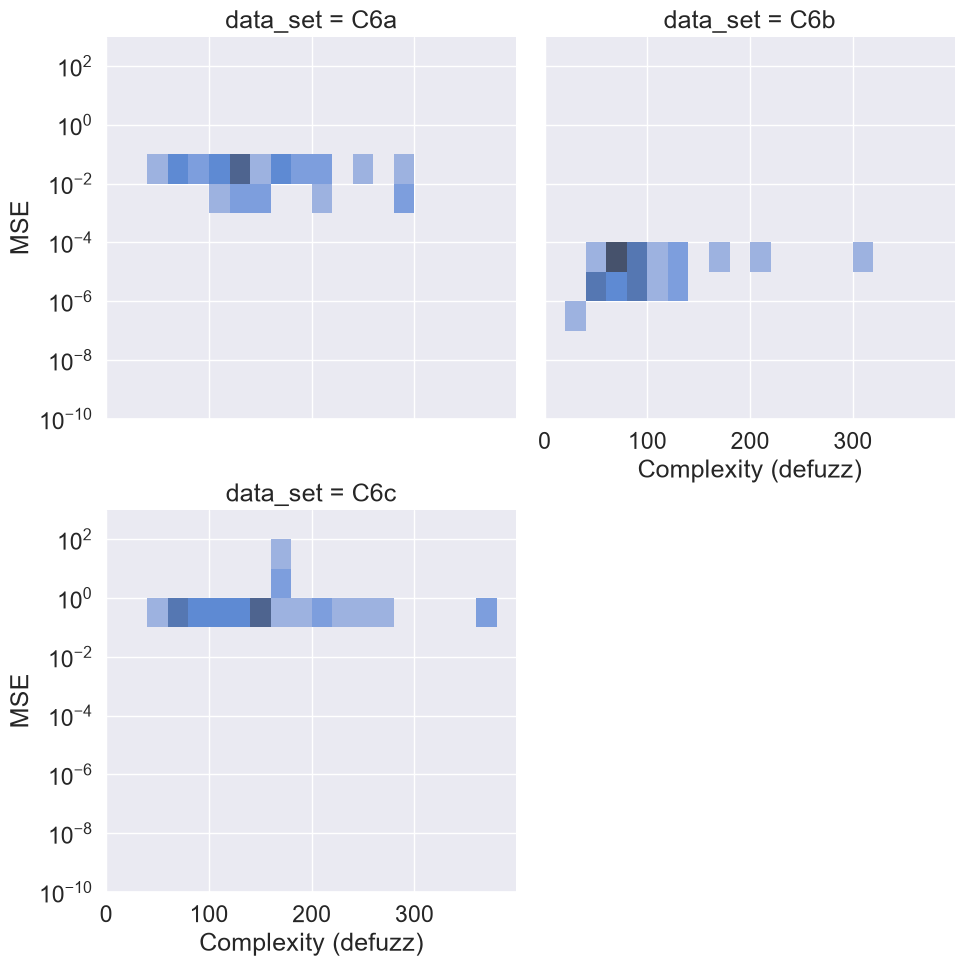

In [79]:
au.complexity_mse_displot(
    srb.loc[data_sets_hard],
    file_stem="srb-hard-complexity-mse-displot",
    **hard_plot_params
)

## Black box

In [80]:
data_sets_C3bb = ["C3a", "C3b", "C3c", "C3d", "C3e", "C3f"]
data_sets_C4bb = ["C4a", "C4b", "C4c", "C4d", "C4e"]
data_sets_black_box = data_sets_C3bb + data_sets_C4bb

In [81]:
srb.loc[srb_min_mse_ixs].loc[data_sets_black_box, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
C3a,32,1.532695e-13,30,0.920158612447882*z**2 + 0.0847316377256921*z ...
C3b,26,3.872880e-14,100,0.0473854062161096*z - 0.309255951972743*(1 + ...
C3c,31,3.390628e-07,192,-1.135613634872*f2*(2*z - 1.43087630777115) + ...
C3d,14,1.662295e-07,199,-0.00033686855290092*f2**4*(-f2 - 0.8621570781...
C3e,20,3.000651e-07,331,0.00892641632230514*H0*(-0.230025243956243*H0*...
C3f,11,1.496931e-07,134,4.68516609956406*Omega_Q0**2 - 7.4916894105047...
C4a,8,2.611376e-02,136,-9.45304957555033*z - 0.0922633571251527*(7.00...
C4b,18,3.660163e-02,95,25.243276950121*f**3 - 69.7749797792664*f*z + ...
C4c,9,3.643609e-02,159,-25.9340443868895*OmM*(2*OomQ + z - 0.19001178...


In the cp3 article, there's no given exact form for these problems, just an order of magnitude for MSE for the best result.
So the best I can do is compare MSE by the power of 10.
```
C3a: better than cp3
C3b: better than cp3
C3c: similar to cp3
C3d: better than cp3
C3e: similar to cp3
C3f: better than cp3
C4a: better than cp3
C4b: similar to cp3
C4c: similar to cp3
C4d: similar to cp3
C4e: worse than cp3
```

In [82]:
black_box_plot_params = {
    "complexity_col": "complexity_defuzz",
    "complexity_lims": (0, 399),
    "complexity_binwidth": 20,
    "mse_lims": (1.0e-15, 1.e-4),
    "mse_binwidth": 0.5,
    "xlabel": "Complexity (defuzz)",
    "ylabel": "MSE"
}

These are the best MSEs from the cp3-bench article.

In [83]:
targets_C3bb = [
    4.2e-13,
    3.6e-11,
    1.4e-7,
    1.3e-6,
    4.6e-7,
    3.8e-6,
    ]
targets_C4bb = [
    4.0e-2,
    3.5e-2,
    3.6e-2,
    1.7e-3,
    4.8e-5,
]
targets_bb = targets_C3bb + targets_C4bb
target_map = dict(zip(data_sets_C3bb + data_sets_C4bb, targets_C3bb + targets_C4bb))

In [84]:
srb.loc[data_sets_black_box, :]

rating           mse  complexity  \
data_set sample_num                                           
C3a      32          2.077104e-11  1.532695e-13          30   
         22          1.942639e-11  2.423109e-13          42   
         25          2.522744e-11  4.218100e-13          43   
         12          1.758714e-11  4.279367e-13          27   
         20          2.061846e-11  5.638932e-13          32   
...                           ...           ...         ...   
C4e      28          9.497698e-05  1.255253e-04         118   
         29          1.015295e-04  1.259813e-04          83   
         32          1.012361e-04  1.264407e-04         184   
         16          9.036274e-05  1.310647e-04          42   
         15          9.367027e-05  1.318952e-04         365   

                     complexity_defuzz  \
data_set sample_num                      
C3a      32                         30   
         22                         42   
         25                         43   
         12                         27   
         20                         32   
...                                ...   
C4e      28                        118   
         29                         83   
         32                        184   
         16                         42   
         15                        345   

                                                                  expr  \
data_set sample_num                                                      
C3a      32          0.9201586124478819*x1**2 + 0.08473163772569212...   
         22          -0.47903728300091586*sqrt(x1) - 0.297467662313...   
         25          -0.5623388256200844*x1**3 - 0.0046861568801673...   
         12          -0.09094992175686768*x1**3 + 0.372762451171327...   
         20          -0.3460499252556381*x1**3 + 0.5534278883385713...   
...                                                                ...   
C4e      28          -1.093817104445662*x1 - 1.5925985688983622*x4*...   
         29          27.79400781052608*x2**2*x4 + 2.862961057471884...   
         32          -9.3481980574030606*x1*x4 - 3.8195060756958975...   
         16          -0.3800515421537456*x1**3 - 2.8749823821534326...   
         15          -0.0006330271982476136*x1 + 15.100456437110541...   

                                                           expr_defuzz  \
data_set sample_num                                                      
C3a      32          0.920158612447882*x1**2 + 0.0847316377256921*x...   
         22          -0.479037283000916*x1**0.5 - 0.29746766231341*...   
         25          -0.562338825620084*x1**3 - 0.00468615688016737...   
         12          -0.0909499217568677*x1**3 + 0.372762451171328*...   
         20          -0.346049925255638*x1**3 + 0.553427888338571*x...   
...                                                                ...   
C4e      28          -1.09381710444566*x1 - 1.59259856889836*x4*(0....   
         29          27.7940078105261*x2**2*x4 + 2.86296105747188*x...   
         32          -9.34819805740306*x1*x4 - 3.8195060756959*x1 +...   
         16          -0.380051542153746*x1**3 - 2.87498238215343*x2...   
         15          -0.000633027198247614*x1 + 15.1004564371105*x2...   

                                                    expr_original_syms  \
data_set sample_num                                                      
C3a      32          0.9201586124478819*z**2 + 0.08473163772569212*...   
         22          -0.47903728300091586*sqrt(z) - 0.2974676623134...   
         25          -0.5623388256200844*z**3 - 0.00468615688016737...   
         12          -0.09094992175686768*z**3 + 0.3727624511713275...   
         20          -0.3460499252556381*z**3 + 0.5534278883385713*...   
...                                                                ...   
C4e      28          -1.093817104445662*OmM - 1.5925985688983622*z*...   
         29          27.79400781052608*OmR**2*z + 2.862961057471884.

In [85]:
srb_bb = srb.loc[data_sets_black_box]

In [86]:
threshold_series = srb_bb.index.get_level_values("data_set").map(target_map)

In [87]:
bb_threshold_counts = (srb_bb.mse <= threshold_series).groupby(level="data_set").sum()
bb_best = srb_bb.mse.groupby(level="data_set").min()

In [88]:
bb_threshold_table = pd.DataFrame({"best": bb_best, "target": targets_bb, "count": bb_threshold_counts}, index=data_sets_black_box)
bb_threshold_table

,best,target,count
C3a,1.532695e-13,4.200000e-13,2
C3b,3.872880e-14,3.600000e-11,32
C3c,3.390628e-07,1.400000e-07,0
C3d,1.662295e-07,1.300000e-06,24
C3e,3.000651e-07,4.600000e-07,4
C3f,1.496931e-07,3.800000e-06,32
C4a,2.611376e-02,4.000000e-02,32
C4b,3.660163e-02,3.500000e-02,0
C4c,3.643609e-02,3.600000e-02,0
C4d,1.039170e-03,1.700000e-03,20


In [89]:
bb_threshold_table.to_csv("Results/bb_threshold_table.csv", index=True, header=True)

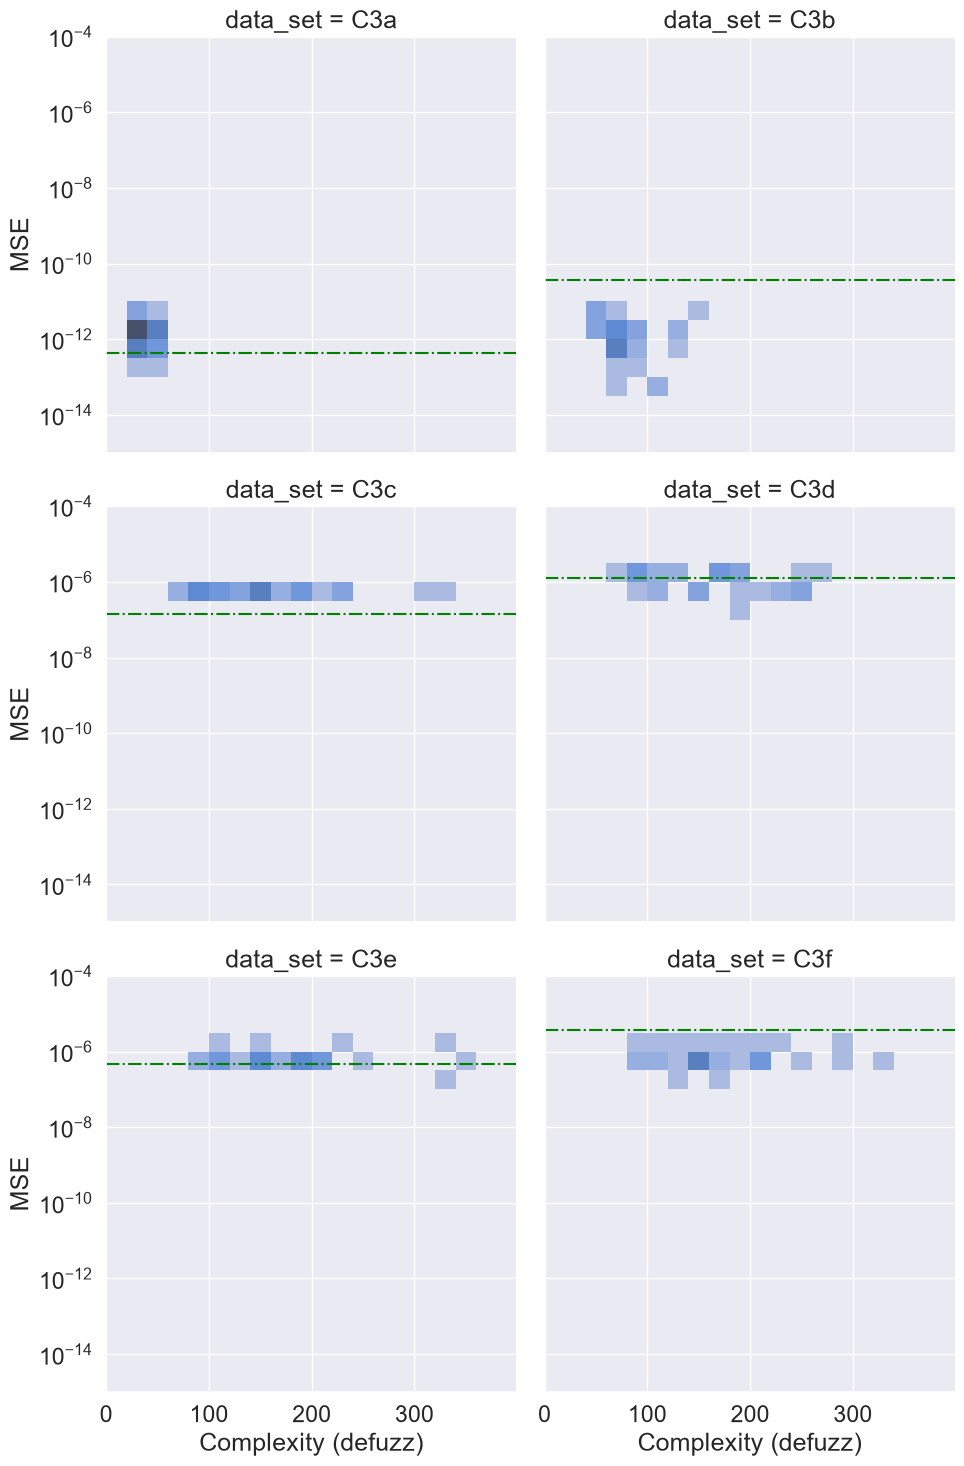

In [90]:
au.complexity_mse_displot(
    srb.loc[data_sets_C3bb],
    file_stem="srb-C3bb-complexity-mse-displot",
    mse_target=targets_C3bb,
    **black_box_plot_params
)

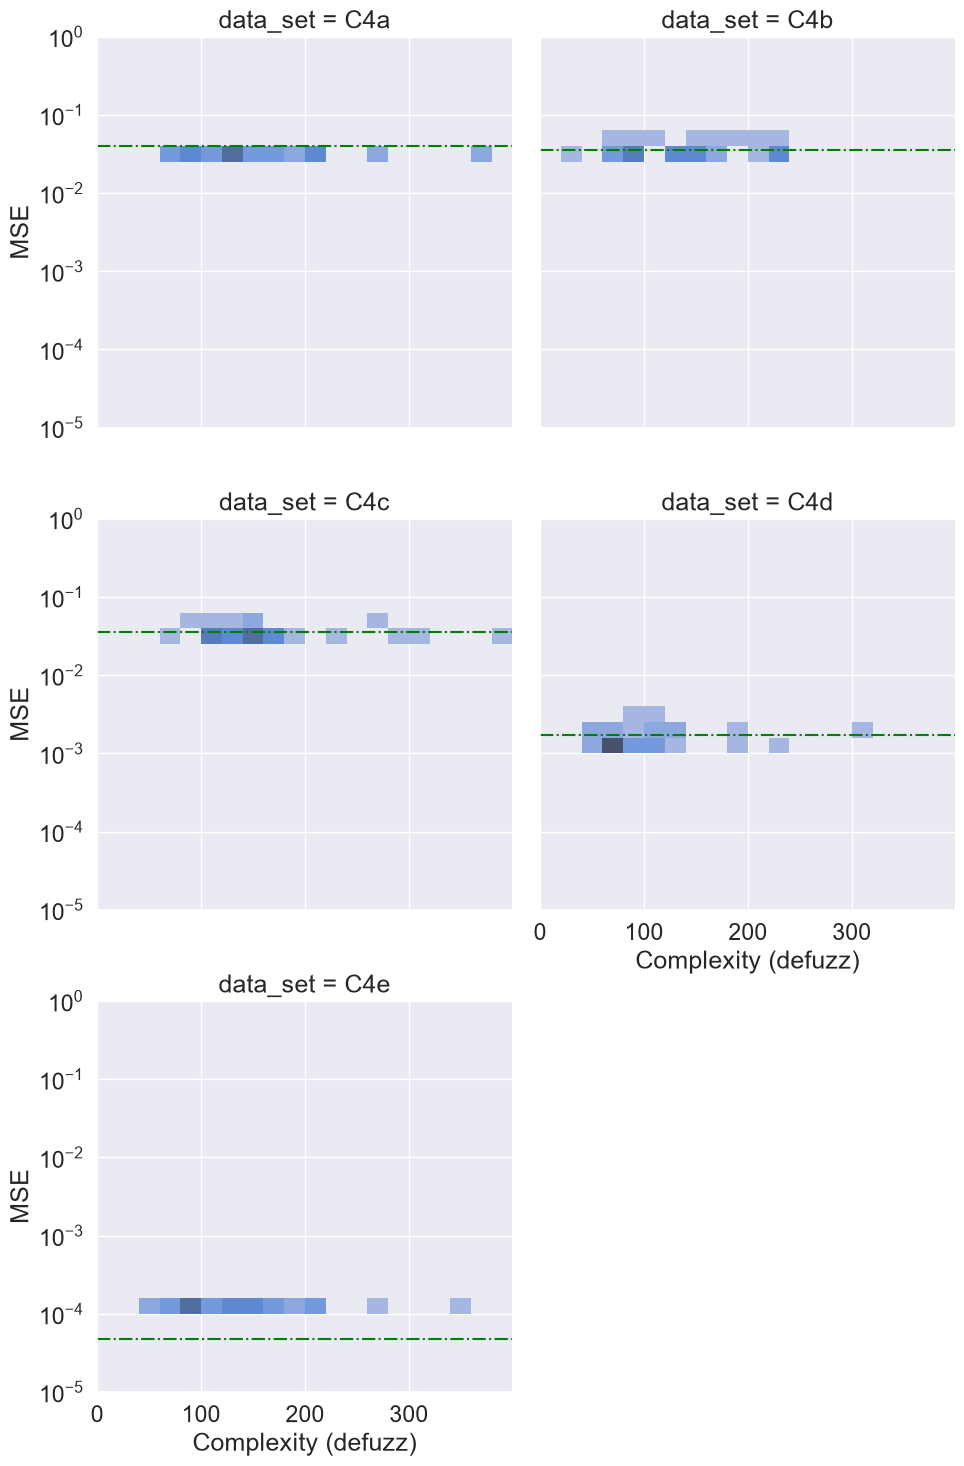

In [91]:
au.complexity_mse_displot(
    srb.loc[data_sets_C4bb],
    file_stem="srb-C4bb-complexity-mse-displot",
    mse_target=targets_C4bb,
    **(black_box_plot_params | { "mse_lims": (1e-5, 1.0), "mse_binwidth": 0.2 })
)

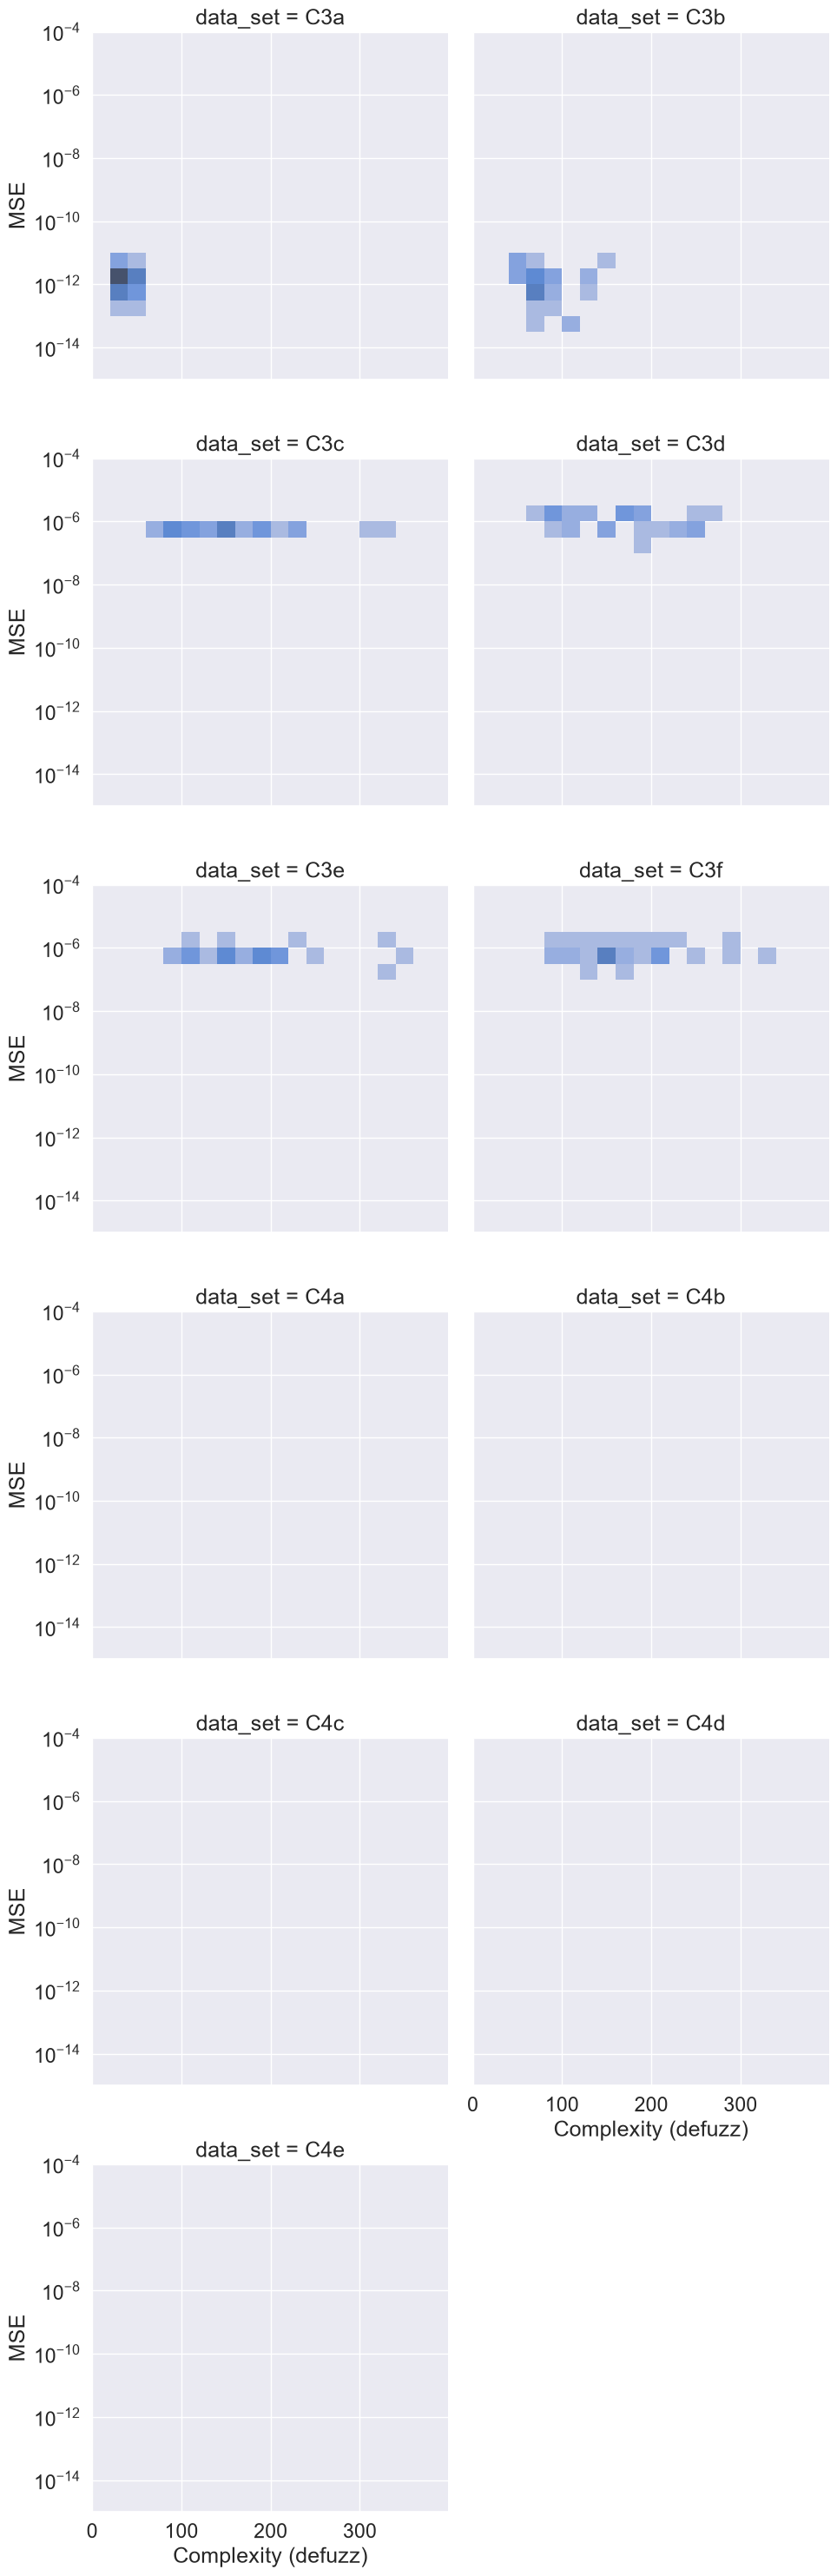

In [92]:
au.complexity_mse_displot(
    srb.loc[data_sets_black_box],
    file_stem="srb-black-box-complexity-mse-displot",
    **black_box_plot_params
)

### More about C3b

Since Jessamine did so much better on C3b, let's see if there's anything to be learned from it.

In [93]:
srb_C3b = srb.loc["C3b"]
srb_C3b

,rating,mse,complexity,complexity_defuzz,expr,expr_defuzz,expr_original_syms,expr_original_syms_defuzz,sympy,sympy_defuzz
sample_num,,,,,,,,,,
26,5.349776e-11,3.872880e-14,100,100,0.047385406216109551*x1 - 0.3092559519727435*(...,0.0473854062161096*x1 - 0.309255951972743*(1 +...,0.047385406216109551*z - 0.3092559519727435*(1...,0.0473854062161096*z - 0.309255951972743*(1 + ...,0.047385406216109551*z - 0.3092559519727435*(1...,0.0473854062161096*z - 0.309255951972743*(1 + ...
32,4.271902e-11,4.910138e-14,78,78,-0.13058755774813214*x1 + 0.003548565224410042...,-0.130587557748132*x1 + 0.00354856522441004*(1...,-0.13058755774813214*z + 0.0035485652244100423...,-0.130587557748132*z + 0.00354856522441004*(1 ...,-0.13058755774813214*z + 0.0035485652244100423...,-0.130587557748132*z + 0.00354856522441004*(1 ...
6,4.220043e-11,5.382296e-14,106,106,-0.092261086213985286*x1 - 0.00842900877054248...,-0.0922610862139853*x1 - 0.00842900877054248*(...,-0.092261086213985286*z - 0.008429008770542482...,-0.0922610862139853*z - 0.00842900877054248*(3...,-0.092261086213985286*z - 0.008429008770542482...,-0.0922610862139853*z - 0.00842900877054248*(3...
27,4.051673e-11,1.211112e-13,60,60,0.9096356961914314*sqrt(x1) + 0.06695061211575...,0.909635696191431*x1**0.5 + 0.066950612115752*...,0.9096356961914314*sqrt(z) + 0.066950612115751...,0.909635696191431*z**0.5 + 0.066950612115752*z...,0.9096356961914314*sqrt(z) + 0.066950612115751...,0.909635696191431*z**0.5 + 0.066950612115752*z...
1,3.852872e-11,3.122379e-13,86,86,-0.0562843833604233*x1 - 0.42976975921089317*(...,-0.0562843833604233*x1 - 0.429769759210893*(0....,-0.0562843833604233*z - 0.42976975921089317*(0...,-0.0562843833604233*z - 0.429769759210893*(0.9...,-0.0562843833604233*z - 0.42976975921089317*(0...,-0.0562843833604233*z - 0.429769759210893*(0.9...
20,3.787143e-11,3.759241e-13,122,120,-0.41179154975715315*x1 + 0.16727443613272114*...,-0.411791549757153*x1 + 0.167274436132721*(x1 ...,-0.41179154975715315*z + 0.16727443613272114*s...,-0.411791549757153*z + 0.167274436132721*(z - ...,-0.41179154975715315*z + (0.36519576421952865*...,-0.411791549757153*z + (0.365195764219529*z - ...
29,5.677116e-11,3.903144e-13,66,66,0.39573098780190942*sqrt(x1) - 0.1447440370786...,0.395730987801909*x1**0.5 - 0.144744037078634*...,0.39573098780190942*sqrt(z) - 0.14474403707863...,0.395730987801909*z**0.5 - 0.144744037078634*z...,0.39573098780190942*sqrt(z) - 0.14474403707863...,0.395730987801909*z**0.5 - 0.144744037078634*z...
10,3.304991e-11,4.055184e-13,64,60,0.01611482554328281*x1 - 0.00414228896893131*(...,0.0161148255432828*x1 - 0.00414228896893131*(2...,0.01611482554328281*z - 0.00414228896893131*(2...,0.0161148255432828*z - 0.00414228896893131*(2 ...,0.01611482554328281*z - 0.00414228896893131*(2...,0.0161148255432828*z - 0.00414228896893131*(2 ...
2,3.696836e-11,4.679555e-13,72,72,0.27161316093038014*x1 - 0.09460648788926303*(...,0.27161316093038*x1 - 0.094606487889263*(-x1 +...,0.27161316093038014*z - 0.09460648788926303*(-...,0.27161316093038*z - 0.094606487889263*(-z + e...,0.27161316093038014*z - 0.09460648788926303*(-...,0.27161316093038*z - 0.094606487889263*(-z + e...


In [94]:
srb_C3b.iloc[0].sympy

0.047385406216109551*z - 0.3092559519727435*(1.0 + exp(-z))**3 - 0.0004250132074574594*((1.0 + exp(-z))**3 + 1.5835951825092973*exp(-2*z + exp(-z)) + 1.0)**3 - 0.008619579057667229*(z + (1.0 + exp(-z))**3 + log(z) + 1.5653023058681397 + exp(-z))**2 - 0.6607118414915816*exp(-2*z + exp(-z)) - 0.0018242715689231422*exp(-2*z + 1.5835951825092973*exp(-2*z + exp(-z))) + 0.1046418945217898*log(z) + 0.5304244923591194 + 0.82287074497147827*exp(-z)

In [95]:
sympy.simplify(srb_C3b.iloc[0].sympy_defuzz)

0.0473854062161096*z - 0.309255951972743*(exp(z) + 1)**3*exp(-3*z) - 0.000425013207457459*((exp(z) + 1)**3 + exp(3*z) + 1.5835951825093*exp(z + exp(-z)))**3*exp(-9*z) - 0.00861957905766723*(z*exp(3*z) + (exp(z) + 1)**3 + exp(3*z)*log(z) + 1.56530230586814*exp(3*z) + exp(2*z))**2*exp(-6*z) - 0.660711841491582*exp(-2*z + exp(-z)) - 0.00182427156892314*exp(-2*z + 1.5835951825092973*exp(-2*z + exp(-z))) + 0.10464189452179*log(z) + 0.530424492359119 + 0.822870744971478*exp(-z)

In [96]:
C3b_expanded = sympy.expand(srb_C3b.iloc[0].sympy_defuzz)
C3b_expanded

-0.00861957905766723*z**2 - 0.0172391581153345*z*log(z) + 0.00316175415161665*z - 0.0689566324613378*z*exp(-z) - 0.0517174743460034*z*exp(-2*z) - 0.0172391581153345*z*exp(-3*z) - 0.00861957905766723*log(z)**2 + 0.0604182424572971*log(z) + 0.161044916419239 - 0.0689566324613378*exp(-z)*log(z) - 0.297092194673191*exp(-z) - 0.00182427156892314*exp(-2*z)*exp(1.5835951825092973*exp(-2*z)*exp(exp(-z))) - 0.668788427905571*exp(-2*z)*exp(exp(-z)) - 0.0517174743460034*exp(-2*z)*log(z) - 1.23660326570556*exp(-2*z) - 0.0242297592419685*exp(-3*z)*exp(exp(-z)) - 0.0172391581153345*exp(-3*z)*log(z) - 0.622826442917496*exp(-3*z) - 0.00639502166815691*exp(-4*z)*exp(2*exp(-z)) - 0.0424020786734448*exp(-4*z)*exp(exp(-z)) - 0.219210102455568*exp(-4*z) - 0.00959253250223537*exp(-5*z)*exp(2*exp(-z)) - 0.0444212252769422*exp(-5*z)*exp(exp(-z)) - 0.112919376219877*exp(-5*z) - 0.00168785425095598*exp(-6*z)*exp(3*exp(-z)) - 0.00959253250223537*exp(-6*z)*exp(2*exp(-z)) - 0.0302871990524606*exp(-6*z)*exp(exp(-z)

In [97]:
f_C3b = sympy.lambdify(z, srb_C3b.iloc[0].sympy_defuzz)

In [98]:
C3b_df = pd.read_csv("Things-to-bench/cosmo_data/C3b.csv")

In [99]:
C3b_df["prediction"] = f_C3b(np.array(C3b_df.z))

In [100]:
C3b_df

,target,z,prediction
0,-3.500434,0.100000,-3.500433
1,-3.490827,0.100901,-3.490826
2,-3.481253,0.101802,-3.481252
3,-3.471714,0.102703,-3.471713
4,-3.462208,0.103604,-3.462208
...,...,...,...
995,-0.328382,0.996396,-0.328383
996,-0.327576,0.997297,-0.327576
997,-0.326771,0.998198,-0.326771
998,-0.325967,0.999099,-0.325967


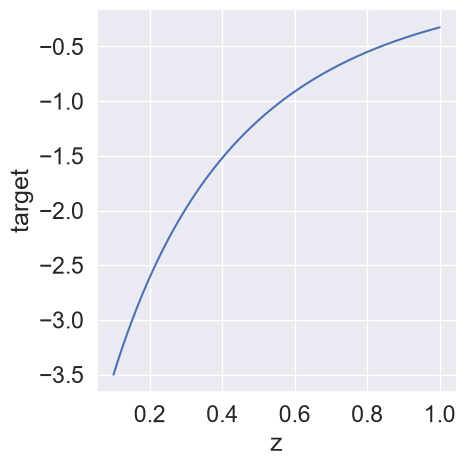

In [101]:
C3b_pic = sns.relplot(data=C3b_df, x="z", y="target", kind="line")
C3b_pic.savefig("Generated/Pictures/C3b_plot.svg")
C3b_pic.savefig("Generated/Pictures/C3b_plot.pdf")

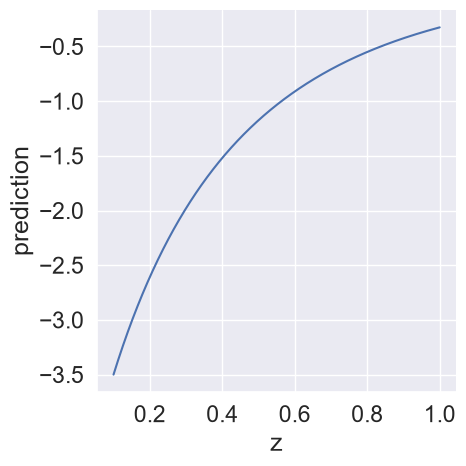

In [102]:
sns.relplot(data=C3b_df, x="z", y="prediction", kind="line")

This pulls apart all the terms.

In [103]:
srb_C3b.iloc[0].sympy.args

(0.5304244923591194,
 0.1046418945217898*log(z),
 0.047385406216109551*z,
 0.82287074497147827*exp(-z),
 -0.008619579057667229*(z + (1.0 + exp(-z))**3 + log(z) + 1.5653023058681397 + exp(-z))**2,
 -0.3092559519727435*(1.0 + exp(-z))**3,
 -0.6607118414915816*exp(-2*z + exp(-z)),
 -0.0004250132074574594*((1.0 + exp(-z))**3 + 1.5835951825092973*exp(-2*z + exp(-z)) + 1.0)**3,
 -0.0018242715689231422*exp(-2*z + 1.5835951825092973*exp(-2*z + exp(-z))))

In [104]:
C3b_terms_fns = [sympy.lambdify(z, term) for term in srb_C3b.iloc[0].sympy.args]

In [105]:
sorted_terms = sorted([(np.linalg.norm(f(C3b_df.z)), j) for f, j in zip(C3b_terms_fns, range(len(C3b_terms_fns)))])
sorted_terms.reverse()
sorted_terms

[(np.float64(42.64949170725982), 5),
 (np.float64(18.87194839406584), 6),
 (np.float64(16.035671793897933), 3),
 (np.float64(10.56104135093838), 4),
 (np.float64(6.357583504057525), 7),
 (np.float64(3.1409477865123945), 1),
 (np.float64(0.9116429216129394), 2),
 (np.float64(0.5304244923591194), 0),
 (np.float64(0.27733498452720173), 8)]

In [106]:
[srb_C3b.iloc[0].sympy.args[j] for _, j in sorted_terms]

[-0.3092559519727435*(1.0 + exp(-z))**3,
 -0.6607118414915816*exp(-2*z + exp(-z)),
 0.82287074497147827*exp(-z),
 -0.008619579057667229*(z + (1.0 + exp(-z))**3 + log(z) + 1.5653023058681397 + exp(-z))**2,
 -0.0004250132074574594*((1.0 + exp(-z))**3 + 1.5835951825092973*exp(-2*z + exp(-z)) + 1.0)**3,
 0.1046418945217898*log(z),
 0.047385406216109551*z,
 0.5304244923591194,
 -0.0018242715689231422*exp(-2*z + 1.5835951825092973*exp(-2*z + exp(-z)))]

In [107]:
sympy.latex(C3b_expanded.evalf(3, chop=True))

'- 0.00862 z^{2} - 0.0172 z \\log{\\left(z \\right)} + 0.00316 z - 0.069 z e^{- z} - 0.0517 z e^{- 2 z} - 0.0172 z e^{- 3 z} - 0.00862 \\log{\\left(z \\right)}^{2} + 0.0604 \\log{\\left(z \\right)} + 0.161 - 0.069 e^{- z} \\log{\\left(z \\right)} - 0.297 e^{- z} - 0.00182 e^{- 2 z} e^{1.5835951825092973 e^{- 2 z} e^{e^{- z}}} - 0.669 e^{- 2 z} e^{e^{- z}} - 0.0517 e^{- 2 z} \\log{\\left(z \\right)} - 1.24 e^{- 2 z} - 0.0242 e^{- 3 z} e^{e^{- z}} - 0.0172 e^{- 3 z} \\log{\\left(z \\right)} - 0.623 e^{- 3 z} - 0.0064 e^{- 4 z} e^{2 e^{- z}} - 0.0424 e^{- 4 z} e^{e^{- z}} - 0.219 e^{- 4 z} - 0.00959 e^{- 5 z} e^{2 e^{- z}} - 0.0444 e^{- 5 z} e^{e^{- z}} - 0.113 e^{- 5 z} - 0.00169 e^{- 6 z} e^{3 e^{- z}} - 0.00959 e^{- 6 z} e^{2 e^{- z}} - 0.0303 e^{- 6 z} e^{e^{- z}} - 0.0456 e^{- 6 z} - 0.0032 e^{- 7 z} e^{2 e^{- z}} - 0.0121 e^{- 7 z} e^{e^{- z}} - 0.0153 e^{- 7 z} - 0.00202 e^{- 8 z} e^{e^{- z}} - 0.00383 e^{- 8 z} - 0.000425 e^{- 9 z}'

In [108]:
C3b_sorted_latex = [sympy.latex(srb_C3b.iloc[0].sympy.args[j].evalf(3, chop=True)) for _, j in sorted_terms]

In [109]:
print("\n".join(C3b_sorted_latex))


- 0.309 \left(1.0 + e^{- z}\right)^{3}
- 0.661 e^{- 2 z + e^{- z}}
0.823 e^{- z}
- 0.00862 \left(z + \left(1.0 + e^{- z}\right)^{3} + \log{\left(z \right)} + 1.57 + e^{- z}\right)^{2}
- 0.000425 \left(\left(1.0 + e^{- z}\right)^{3} + 1.58 e^{- 2 z + e^{- z}} + 1.0\right)^{3}
0.105 \log{\left(z \right)}
0.0474 z
0.53
- 0.00182 e^{- 2 z + 1.5835951825092973 e^{- 2 z + e^{- z}}}


In [110]:
C3b_truncated = sympy.Add(*[srb_C3b.iloc[0].sympy.args[j] for j in range(8)])
C3b_truncated

0.047385406216109551*z - 0.3092559519727435*(1.0 + exp(-z))**3 - 0.0004250132074574594*((1.0 + exp(-z))**3 + 1.5835951825092973*exp(-2*z + exp(-z)) + 1.0)**3 - 0.008619579057667229*(z + (1.0 + exp(-z))**3 + log(z) + 1.5653023058681397 + exp(-z))**2 - 0.6607118414915816*exp(-2*z + exp(-z)) + 0.1046418945217898*log(z) + 0.5304244923591194 + 0.82287074497147827*exp(-z)

In [111]:
f_C3b_truncated = sympy.lambdify(z, sympy.Add(*[srb_C3b.iloc[0].sympy.args[j] for j in range(8)]))

In [112]:
C3b_df["prediction_truncated"] = f_C3b_truncated(np.array(C3b_df.z))

In [113]:
C3b_df

,target,z,prediction,prediction_truncated
0,-3.500434,0.100000,-3.500433,-3.463628
1,-3.490827,0.100901,-3.490826,-3.454394
2,-3.481253,0.101802,-3.481252,-3.445189
3,-3.471714,0.102703,-3.471713,-3.436013
4,-3.462208,0.103604,-3.462208,-3.426866
...,...,...,...,...
995,-0.328382,0.996396,-0.328383,-0.328043
996,-0.327576,0.997297,-0.327576,-0.327237
997,-0.326771,0.998198,-0.326771,-0.326433
998,-0.325967,0.999099,-0.325967,-0.325630


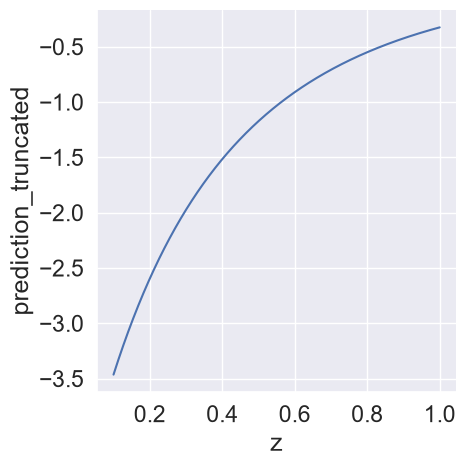

In [114]:
sns.relplot(data=C3b_df, x="z", y="prediction_truncated", kind="line")

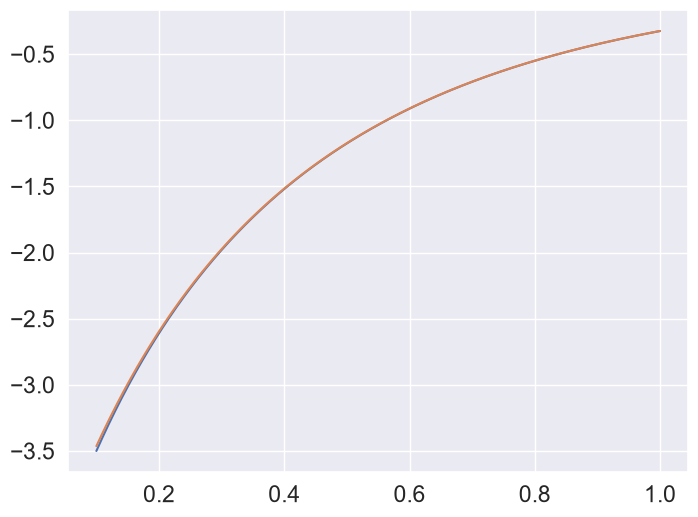

In [115]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(C3b_df.z, C3b_df.target, label="target")
ax.plot(C3b_df.z, C3b_df.prediction_truncated, label="pred trunc")
# ax.plot(C3b_df.z, 0.105*np.log(C3b_df.z) + 0.0474*C3b_df.z + 0.53, label="linear+log")

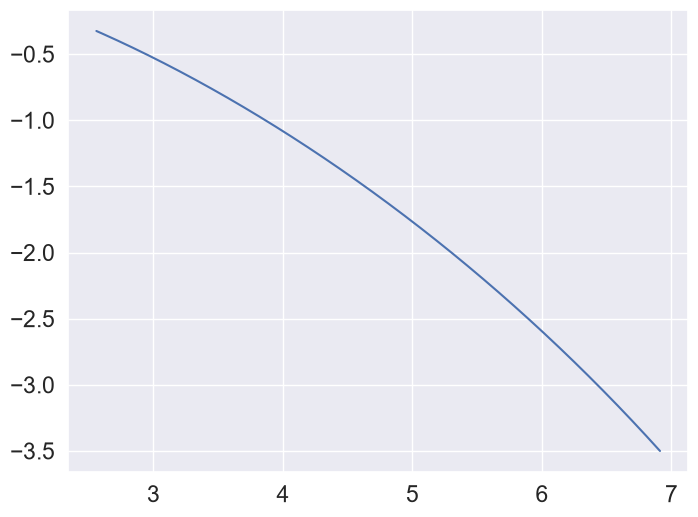

In [116]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot((1+np.exp(-C3b_df.z))**3, C3b_df.target, label="target")
# ax.plot(C3b_df.z, 0.105*np.log(C3b_df.z) + 0.0474*C3b_df.z + 0.53, label="linear+log")

In [117]:
sympy.series(1 + sympy.exp(-z), z, 0, 4)

2 - z + z**2/2 - z**3/6 + O(z**4)

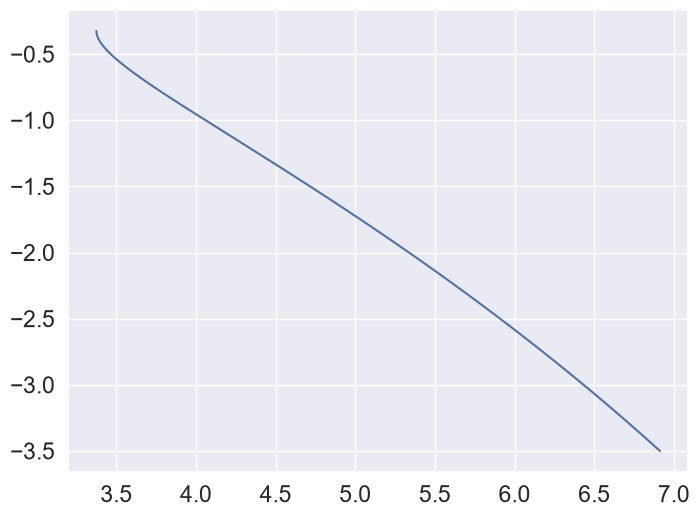

In [118]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot((2 - C3b_df.z + 0.5*C3b_df.z**2)**3, C3b_df.target, label="target")
# ax.plot(C3b_df.z, 0.105*np.log(C3b_df.z) + 0.0474*C3b_df.z + 0.53, label="linear+log")

### Cheating with progressive inventory

Cheating isn't really possible because we don't know what hint to give.
Using the progressive inventories:

In [119]:
cht.loc[cht_min_mse_ixs].loc[data_sets_black_box, ["mse", "complexity_defuzz", "sympy_defuzz"]]

,,mse,complexity_defuzz,sympy_defuzz
data_set,sample_num,,,
C3a,31,1.302673e-14,79,-0.0629192220637877*z**0.5 - 0.044490608588286...
C3b,22,2.285324e-14,175,0.384050510651796*z + 0.431084287498535*(-2 - ...
C3c,30,1.641539e-07,632,0.0103874105594704*f2**2*(z - 0.45228522999430...
C3d,4,5.214869e-07,661,0.945814907730973*f2**2 - 0.0142783569564398*f...
C3e,3,1.182947e-07,399,100.471128876825*H0**2 + 0.0923725693917978*H0...
C3f,32,3.436308e-07,257,-0.420684783983125*H0*(Omega_Q0 + 2)*(Omega_m0...
C4a,19,3.534703e-02,161,0.289814633933797*z**2 - 15.6259565777373*z + ...
C4b,18,3.615518e-02,113,39.1284985611302*f**2*z**2*(f + 1)*(z + 5.6408...
C4c,20,3.633120e-02,71,22.4179258472913*OmM*z**4*(-OmR + 0.0558338828...


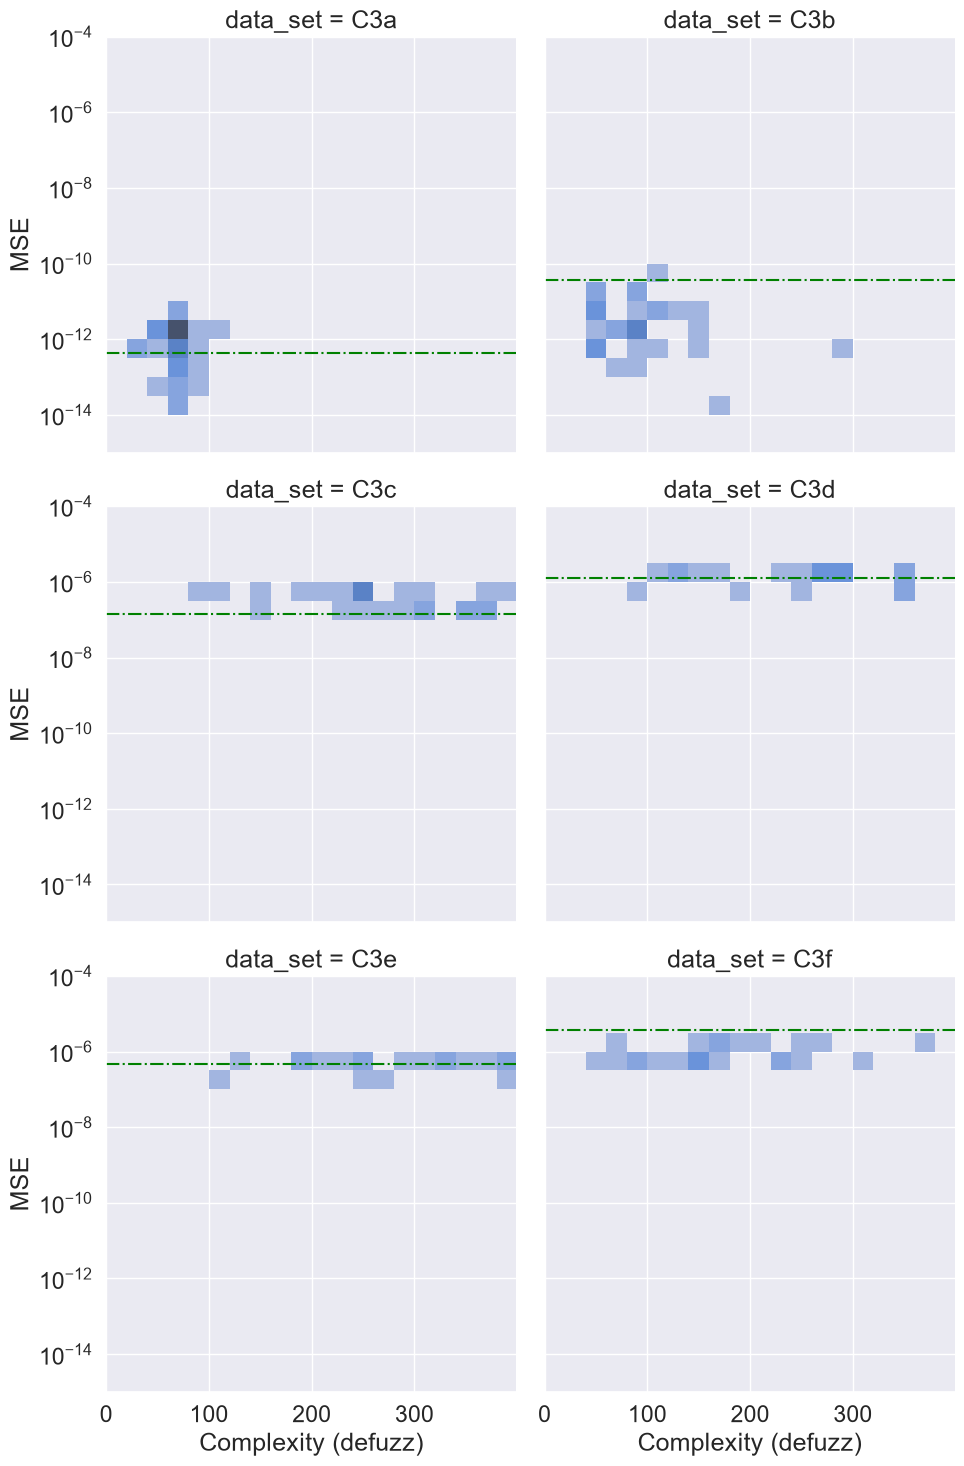

In [120]:
au.complexity_mse_displot(
    cht.loc[data_sets_C3bb],
    file_stem="cht-C3bb-complexity-mse-displot",
    mse_target=targets_C3bb,
    **black_box_plot_params
)

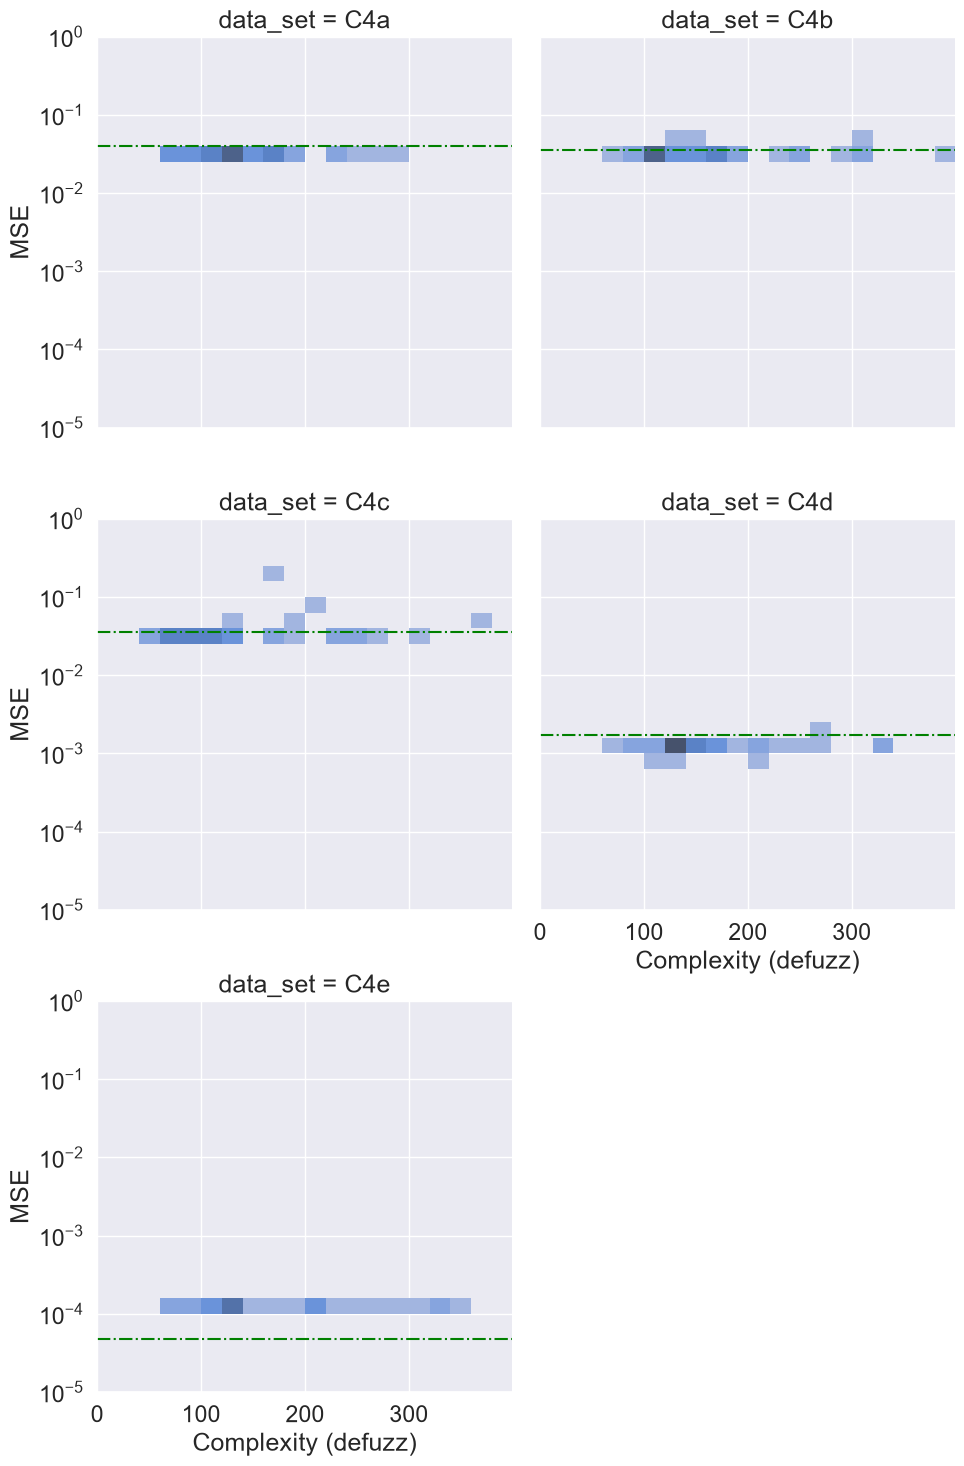

In [121]:
au.complexity_mse_displot(
    cht.loc[data_sets_C4bb],
    file_stem="cht-C4bb-complexity-mse-displot",
    mse_target=targets_C4bb,
    **(black_box_plot_params | { "mse_lims": (1e-5, 1.0), "mse_binwidth": 0.2 })
)